In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax
print("JAX device:", jax.devices())
jax.config.update('jax_disable_jit', False) # Turn off JIT because of an issue in shortwave_radiation.py:169
jax.config.update("jax_debug_infs", True) # doesn't add any time since the saved time is otherwise spent getting the nodal quantities
jax.config.update("jax_debug_nans", False) # some physics fields might be nan

JAX device: [CpuDevice(id=0)]


In [2]:
import sys
from pathlib import Path

paths_check = [
    (Path(os.path.abspath(".")) / ".." / ".." / "jax-gcm").resolve(),
    (Path(os.path.abspath(".")) / "..").resolve(),
]

for module_path in paths_check:
    module_path = str(module_path)
    if module_path in sys.path:
        print("Path exist: ", module_path)
    else:
        print("Add Path: ", module_path)
        sys.path.append(module_path)


Add Path:  /home/t2hsu/projects/jax-gcm
Add Path:  /home/t2hsu/projects/jax-esm


In [3]:
import numpy as np
import xarray as xr
import pandas as pd

#import jcm
#from jcm.model import Model, get_coords
#from jcm.boundaries import initialize_boundaries

from jax_esm.Master import Master
from jax_esm.components.base import ComponentConfig
from jax_esm.components.Speedy import Speedy
from jax_esm.components.SlabOceanModel import SlabOceanModel
from jax_esm.components.FluxModel import FluxModel

Path exist:  /home/t2hsu/projects/jax-gcm
Path exist:  /home/t2hsu/projects/jax-esm


# Create Model

In [4]:
total_simulation_time =  20 * 86400.0 
master_time_step      =  24 *  3600.0  # sec
master_steps = int(total_simulation_time / master_time_step)

atm_substeps          =  24           # count
atm_save_interval     =  master_time_step # sec

ocn_substeps          =  1            # count
ocn_save_interval     = 24 *  3600.0  # sec

flx_substeps          =  1            # count
flx_save_interval     = 24 *  3600.0  # sec



In [5]:
# Master Config
config_master = dict(
    total_simulation_time = total_simulation_time,
    time_step = master_time_step,
)

# Atmosphere model
config_atm = ComponentConfig(
    name = "atm",
    timestep = master_time_step,
    substeps = atm_substeps,
    save_interval = atm_save_interval,
    grid = None,
    params = None,
)

model_atm = Speedy(
    config = config_atm,
)

# Ocean model
config_ocn = ComponentConfig(
    name = "ocn",
    timestep = master_time_step,
    substeps = ocn_substeps,
    save_interval = ocn_save_interval,
    grid = None,
    params = None,
)
model_ocn = SlabOceanModel(config_ocn)

# Flux model
config_flx = ComponentConfig(
    name = "flx",
    timestep = master_time_step,
    substeps = flx_substeps,
    save_interval = flx_save_interval,
    grid = None,
    params = None,
)
model_flx = FluxModel(config_flx)

In [6]:
master = Master(
    config = config_master,
    components = dict(
        flx = model_flx,
        atm = model_atm,
        ocn = model_ocn,
    ), 
)

master.data_center.registerAlias(
    varname_universal = "surface_air_temperature",
    component         = "atm",
    varname_component = "surface_temperature",
)



master.checkPlan()
master.printPlan()

import time

t0 = time.time()

state = model_atm.model.get_initial_state()
#final_state, predictions = model.unroll(state)

t1 = time.time()

total_time = t1-t0
print(f"Total time: {total_time:.1f} s.")

Print execution plan:
[ 1] : flx 
[ 2] : atm 
[ 3] : ocn 
Total time: 0.0 s.


In [7]:
record_atm_varnames = [
    "normalized_surface_pressure",
    "u_wind",
    "v_wind", 
    "specific_humidity", 
    "temperature", 
    "shortwave_rad.cloudc",
    "shortwave_rad.qcloud",
    "shortwave_rad.icltop",
    "shortwave_rad.cloudstr",
]
atm_recorder = { varname : [] for varname in record_atm_varnames }

def record_atm(step):
    atm = master.components["atm"]
    pred_ds = atm.model.predictions_to_xarray(atm.speedy_holder["tmp_pred"])
    for varname in record_atm_varnames:
        ds = pred_ds[varname]
        t = ds.coords["time"].to_numpy()
        t += pd.Timedelta(days=step)
        ds = ds.assign_coords(dict(
            time = t,
        ))
        atm_recorder[varname].append(ds)



# Run the Model

In [8]:
for step in range(master_steps):
    print(f"Master Step: {step:d}/{master_steps:d}")
    master.run()
    record_atm(step)



Master Step: 0
Master Step: 1
Master Step: 2
Master Step: 3
Master Step: 4
Master Step: 5
Master Step: 6
Master Step: 7
Master Step: 8
Master Step: 9
Master Step: 10
Master Step: 11
Master Step: 12
Master Step: 13
Master Step: 14
Master Step: 15
Master Step: 16
Master Step: 17
Master Step: 18
Master Step: 19


In [9]:
print("Merge")
merged = dict()
for varname in record_atm_varnames:
    merged[varname] = xr.merge(atm_recorder[varname])[varname]


Merge


In [10]:
merged["normalized_surface_pressure"]

<xarray.DataArray 'normalized_surface_pressure' (time: 20, lon: 96, lat: 48)> Size: 369kB
Array([[[1.0000027 , 0.99999803, 1.0000083 , ..., 1.0000079 ,
         0.99999577, 0.9999994 ],
        [1.0000027 , 0.999998  , 1.0000083 , ..., 1.0000079 ,
         0.99999577, 0.9999994 ],
        [1.0000027 , 0.999998  , 1.0000083 , ..., 1.0000079 ,
         0.9999957 , 0.9999994 ],
        ...,
        [1.0000029 , 0.9999981 , 1.0000083 , ..., 1.0000079 ,
         0.9999958 , 0.99999946],
        [1.0000029 , 0.9999981 , 1.0000083 , ..., 1.0000079 ,
         0.9999958 , 0.99999946],
        [1.0000029 , 0.99999803, 1.0000083 , ..., 1.0000079 ,
         0.99999577, 0.99999946]],

       [[1.0002017 , 1.0001743 , 1.0001897 , ..., 1.0003711 ,
         1.0003636 , 1.000413  ],
        [1.0002017 , 1.0001743 , 1.0001897 , ..., 1.0003711 ,
         1.0003636 , 1.000413  ],
        [1.0002017 , 1.0001743 , 1.0001897 , ..., 1.0003711 ,
         1.0003636 , 1.000413  ],
...
        [1.0030292 , 1.0014759 , 1.0015848 , ..., 1.0051731 ,
         1.0052502 , 1.00614   ],
        [1.0030328 , 1.0014948 , 1.0016148 , ..., 1.0051833 ,
         1.0052617 , 1.0061421 ],
        [1.0030377 , 1.0015175 , 1.0016509 , ..., 1.0051955 ,
         1.0052729 , 1.006144  ]],

       [[1.0033617 , 1.0020516 , 1.0024344 , ..., 1.0052029 ,
         1.0052968 , 1.0070993 ],
        [1.0033447 , 1.0020102 , 1.0023743 , ..., 1.0051883 ,
         1.0053022 , 1.0071075 ],
        [1.0033284 , 1.0019673 , 1.0023087 , ..., 1.0051705 ,
         1.0053053 , 1.0071156 ],
        ...,
        [1.0034156 , 1.0021617 , 1.0025635 , ..., 1.00522   ,
         1.0052657 , 1.0070742 ],
        [1.0033972 , 1.0021278 , 1.0025301 , ..., 1.0052191 ,
         1.0052786 , 1.0070826 ],
        [1.0033792 , 1.0020909 , 1.0024868 , ..., 1.0052133 ,
         1.005289  , 1.0070909 ]]], dtype=float32)
Coordinates:
  * lon      (lon) float64 768B 0.0 3.75 7.5 11.25 ... 345.0 348.8 352.5 356.2
  * lat      (lat) float64 384B -87.16 -83.48 -79.78 ... 79.78 83.48 87.16
  * time     (time) datetime64[ns] 160B 2000-01-01 2000-01-02 ... 2000-01-20
Attributes:
    units:    1

# Plot the Results

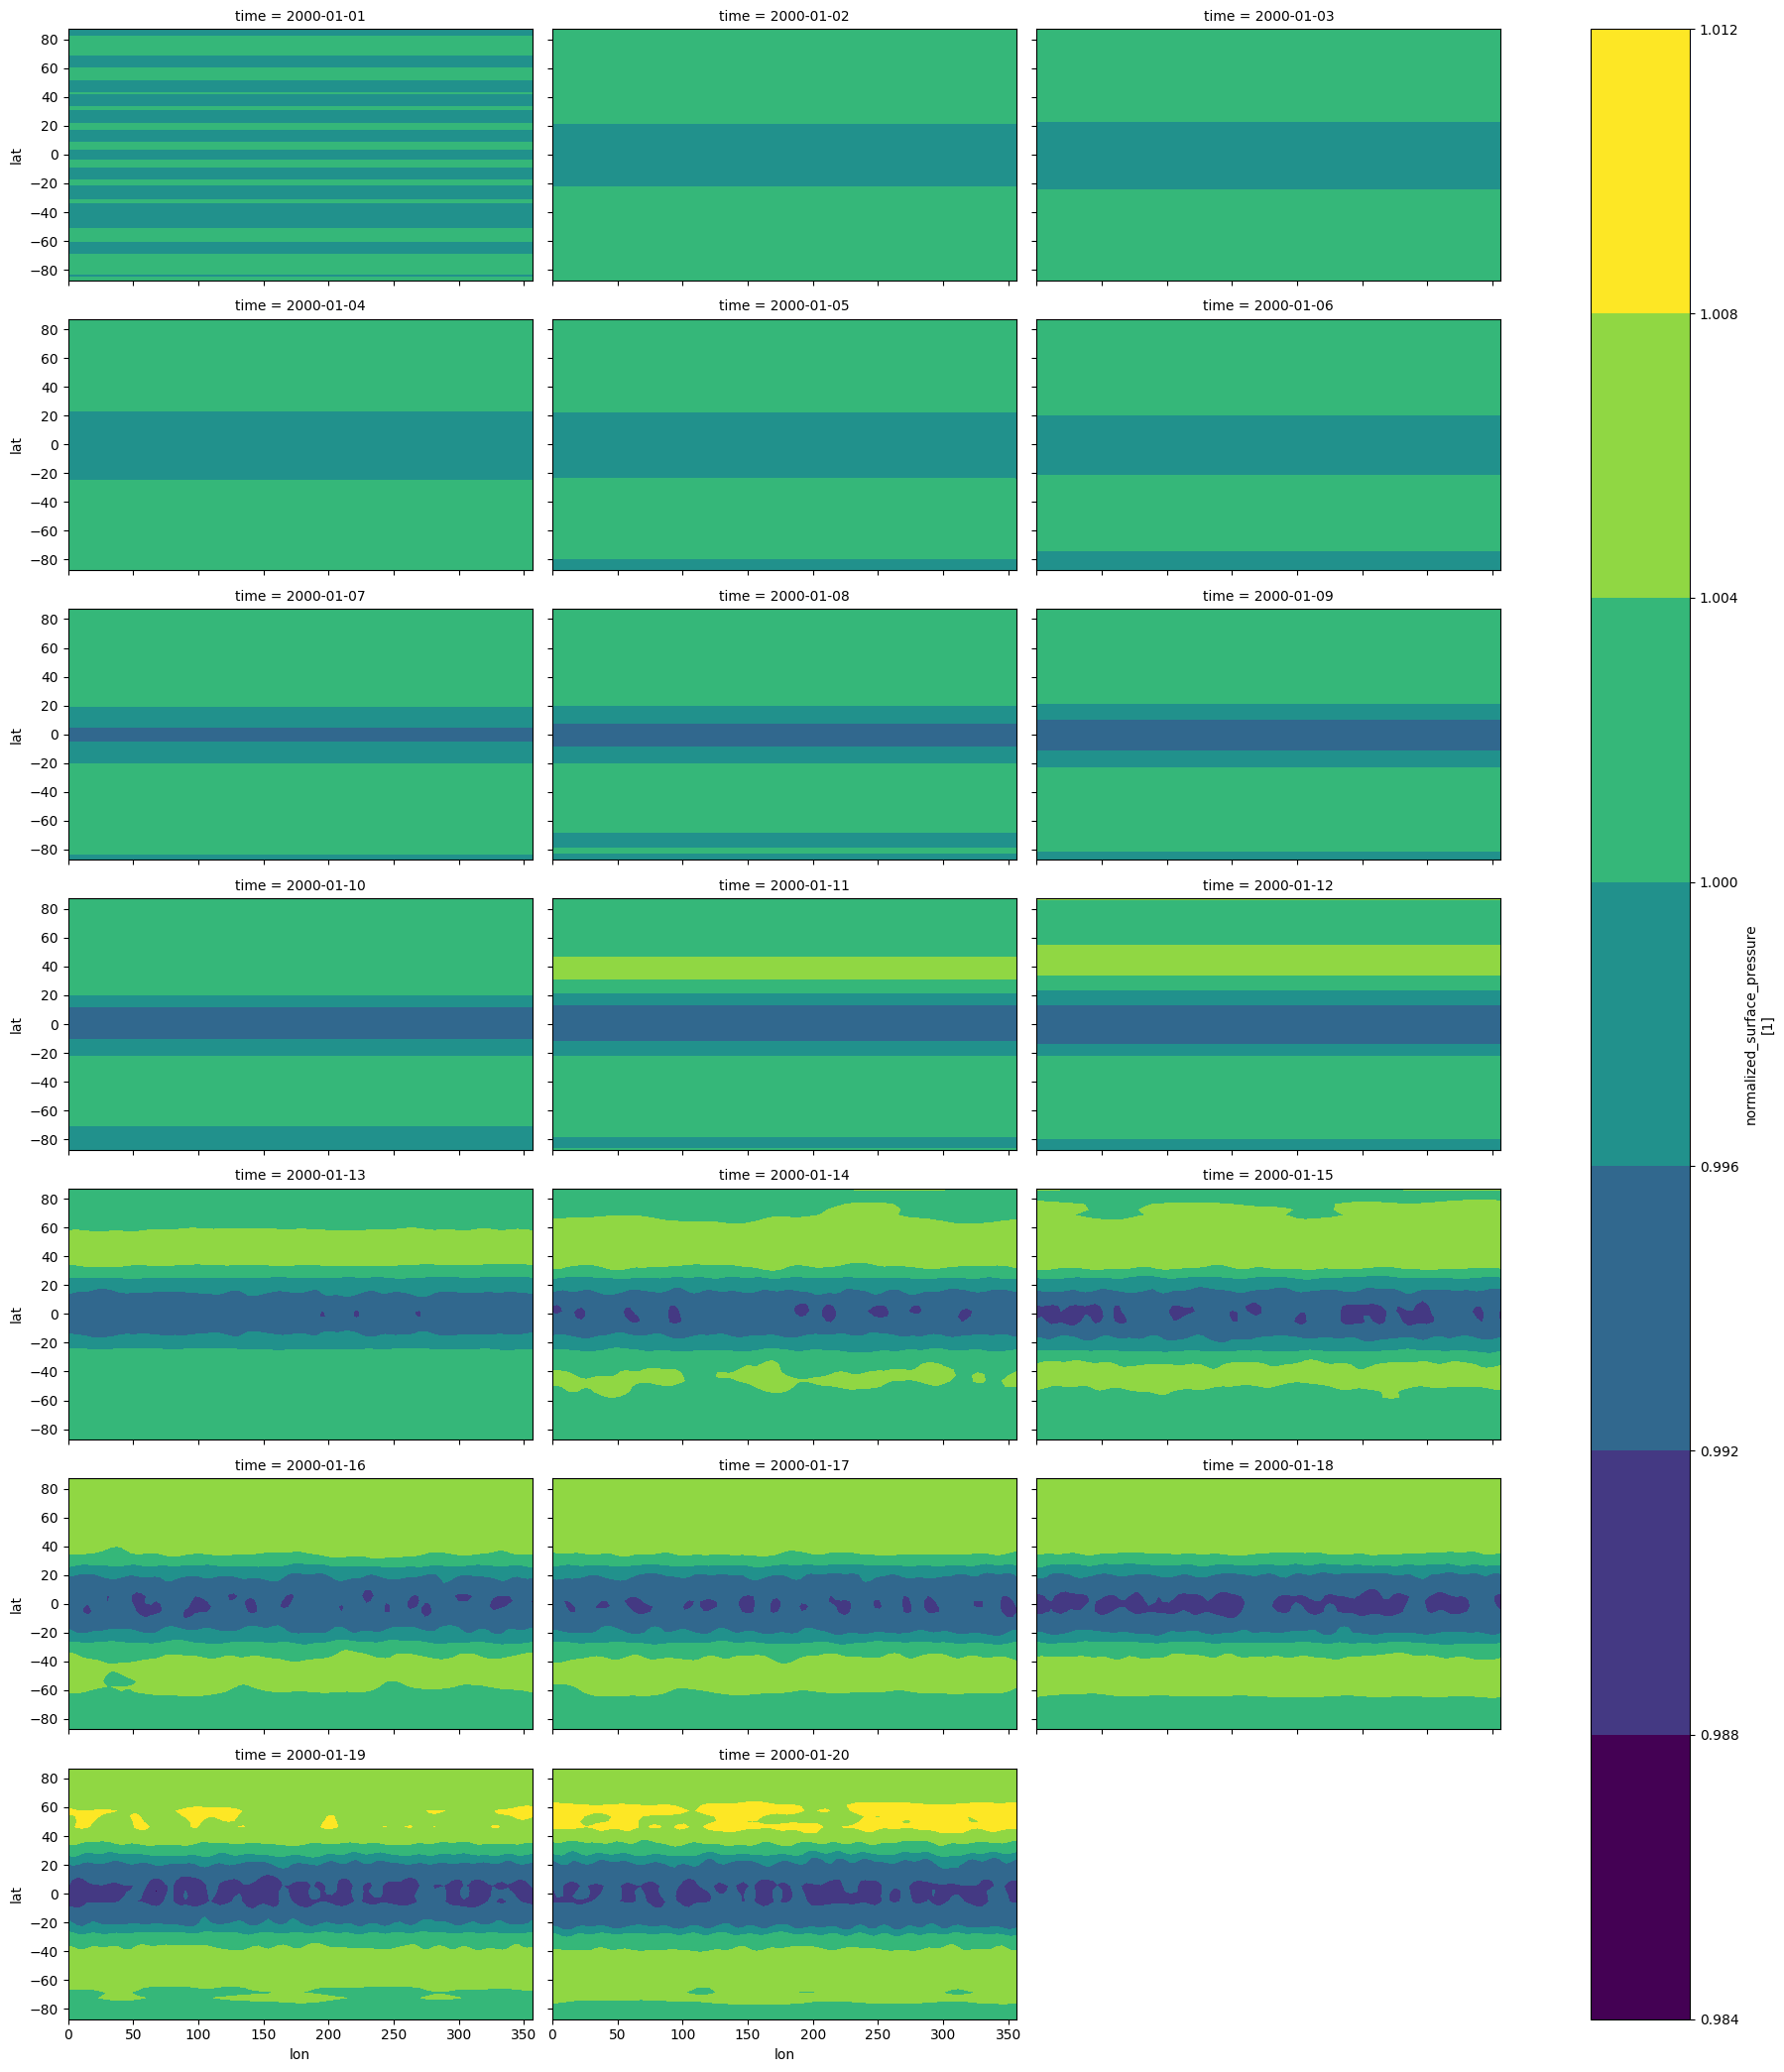

In [11]:
#import matplotlib.pyplot as plt

merged['normalized_surface_pressure'].plot.contourf(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

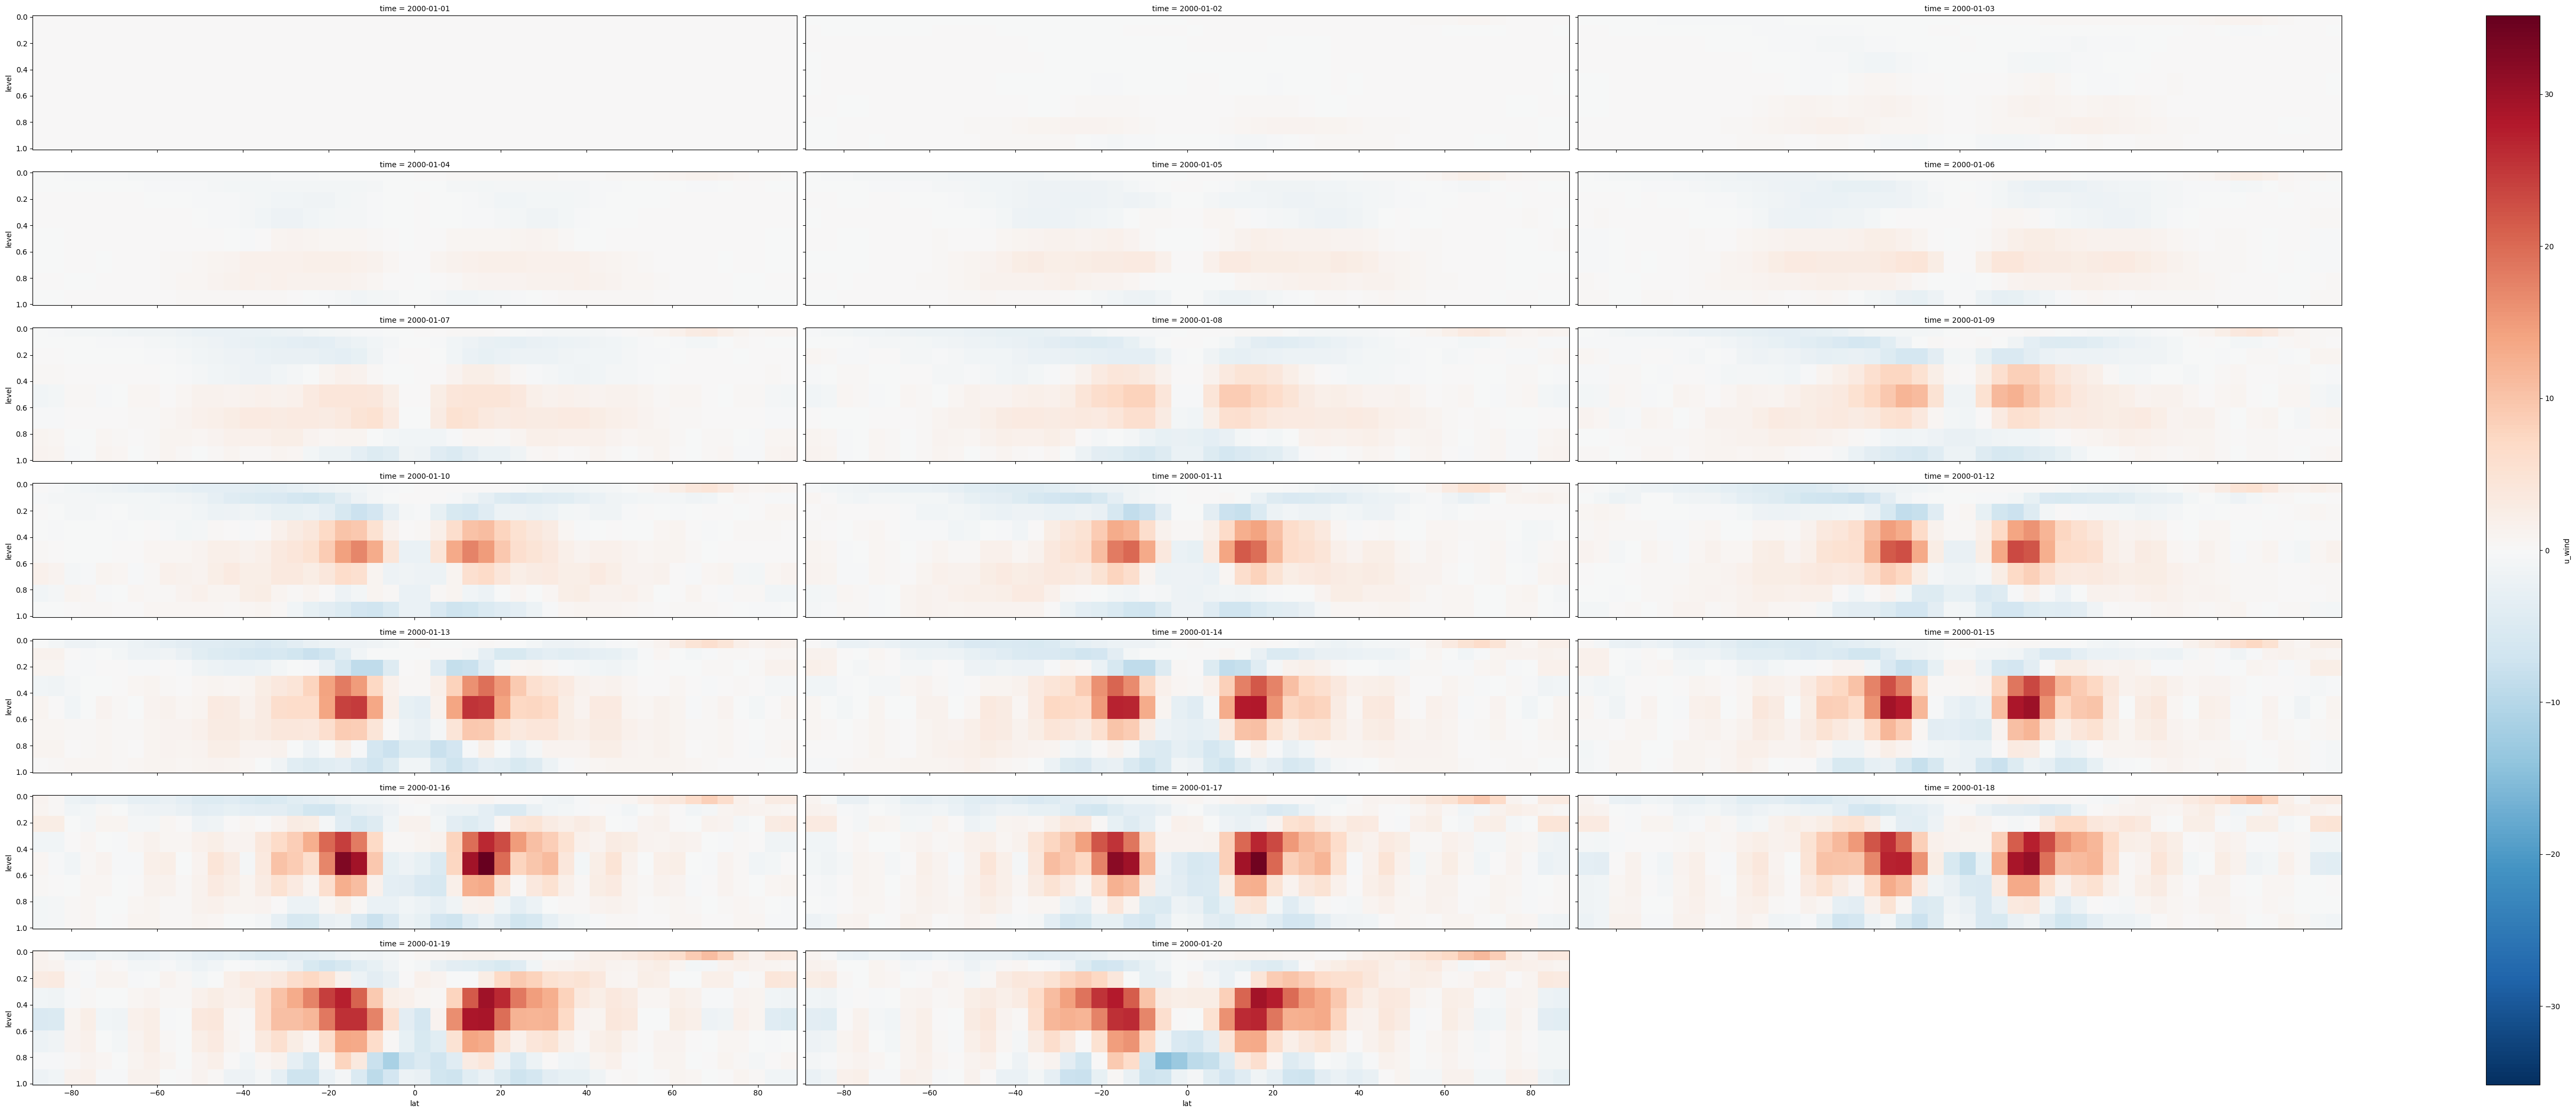

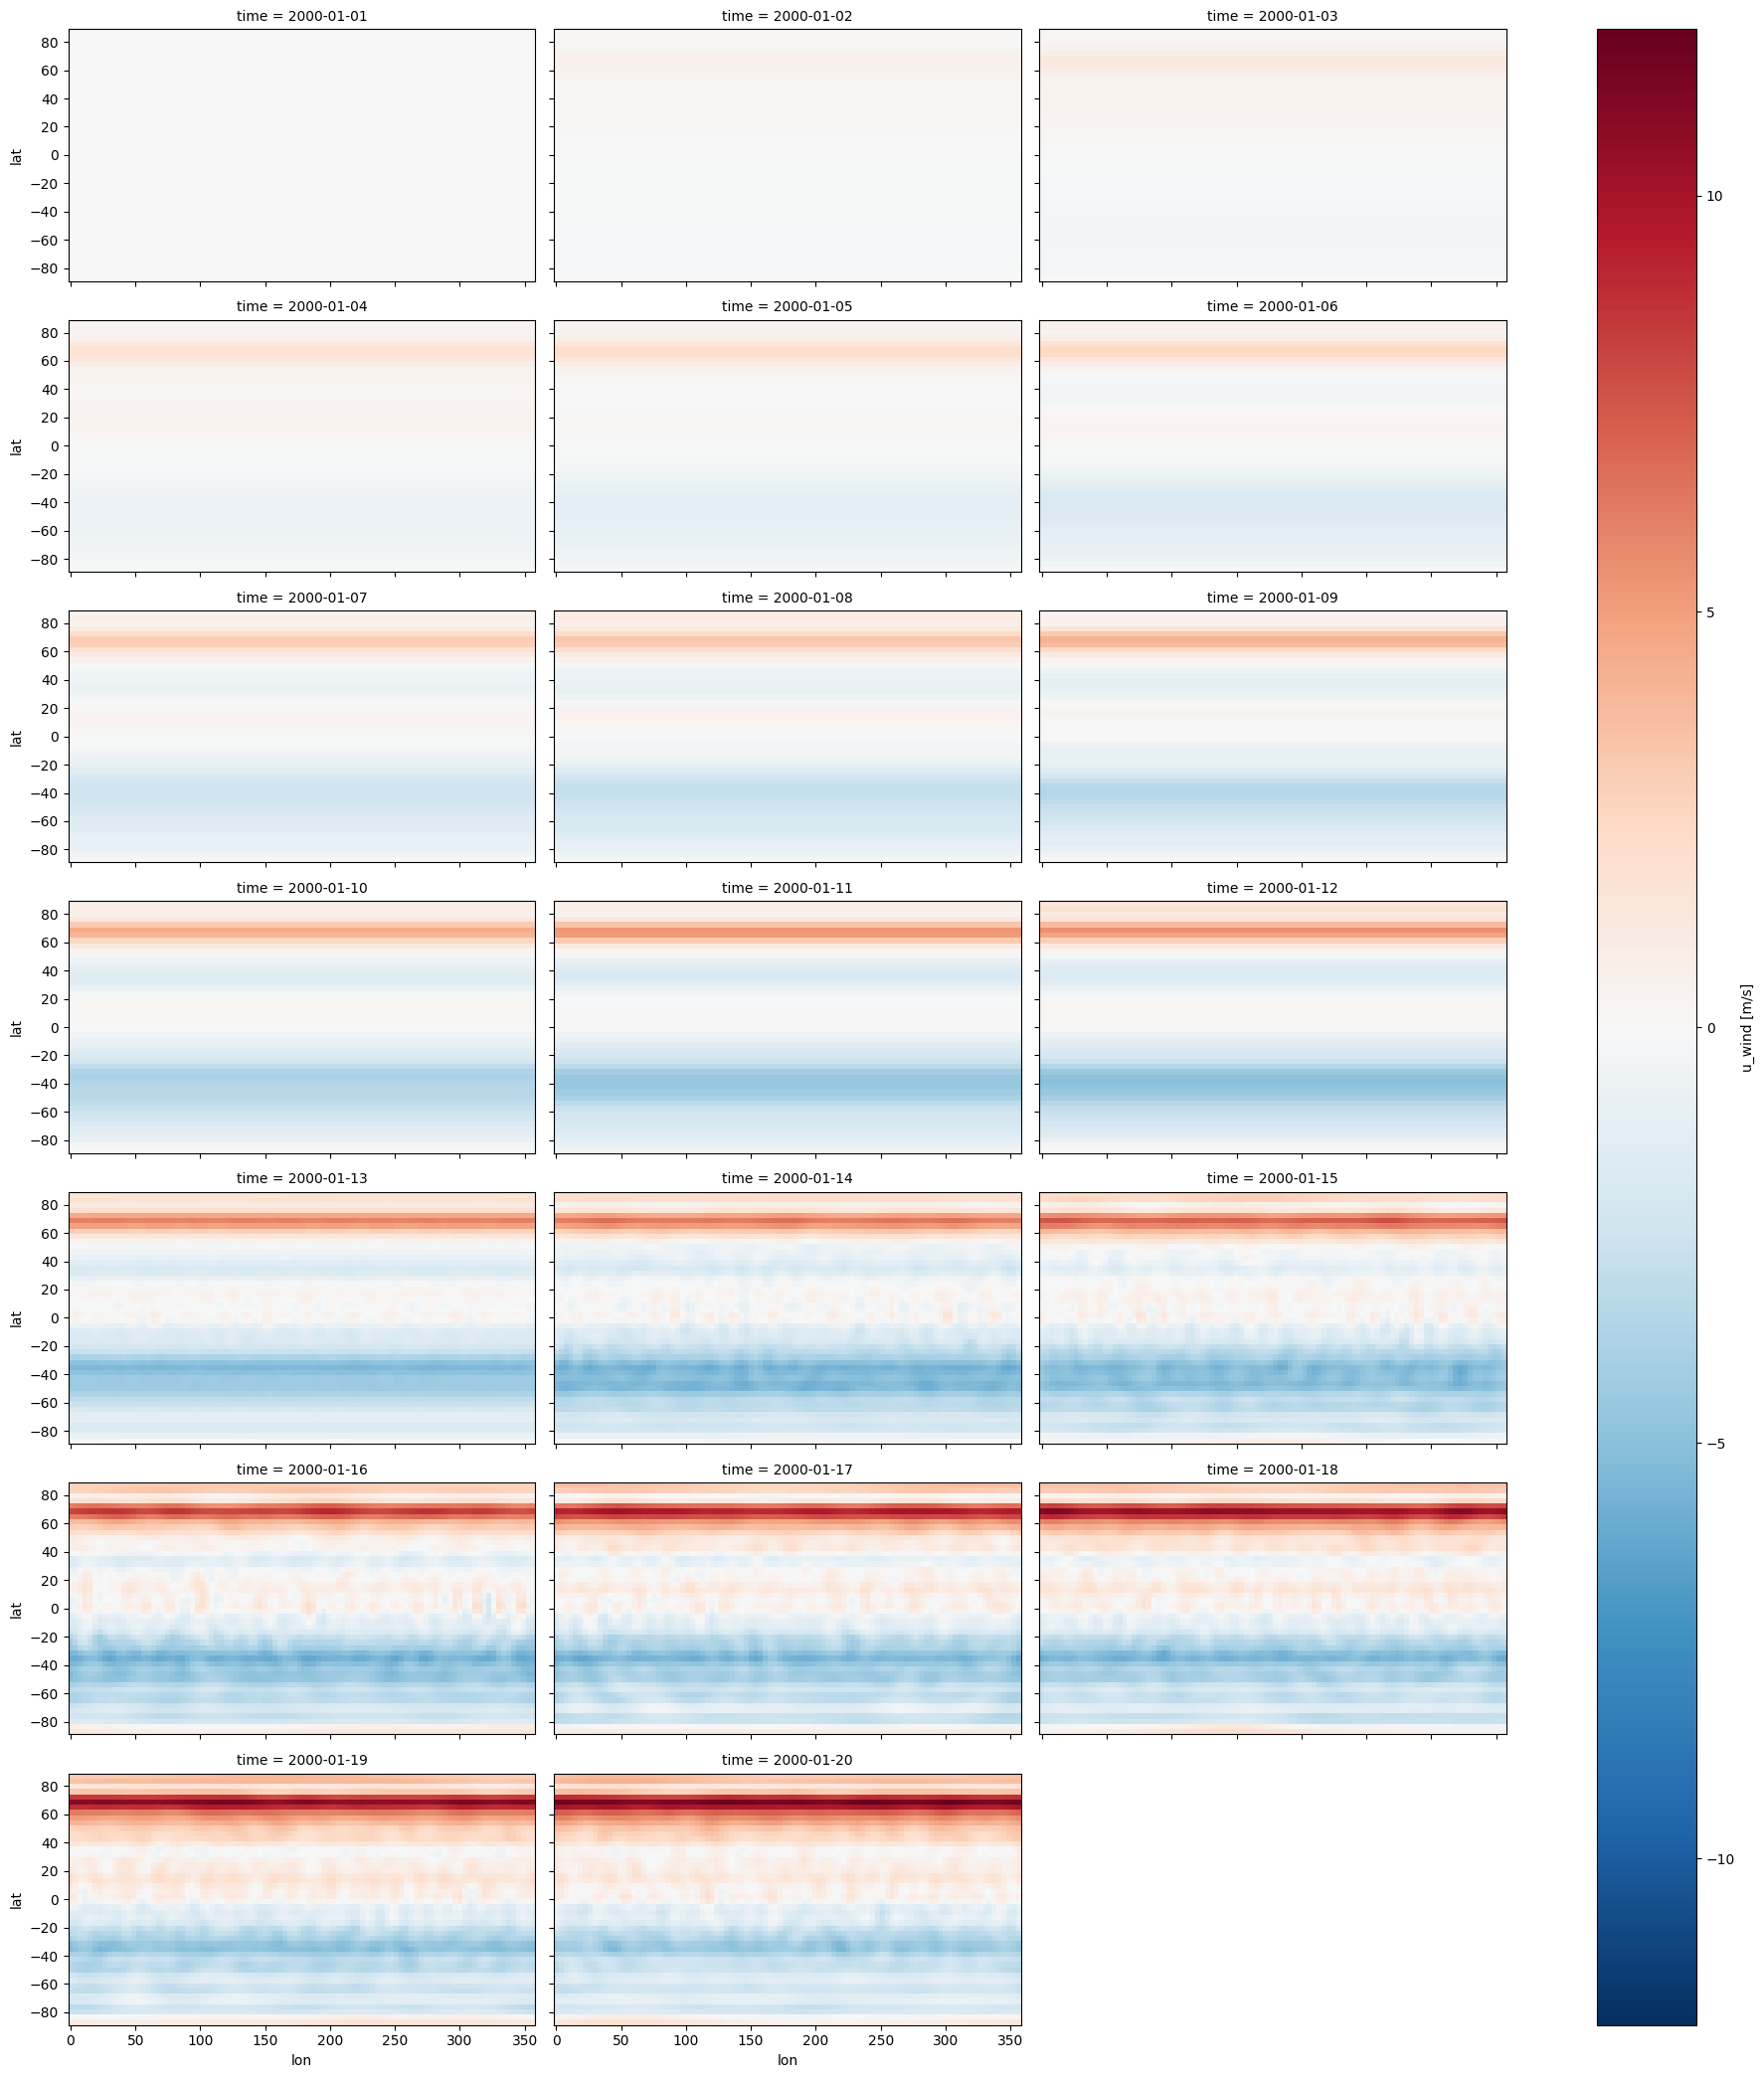

In [12]:
merged['u_wind'].mean('lon').plot(x='lat', y='level', col='time', col_wrap=3, aspect=6, yincrease=False)
merged['u_wind'].isel(level=-1).plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

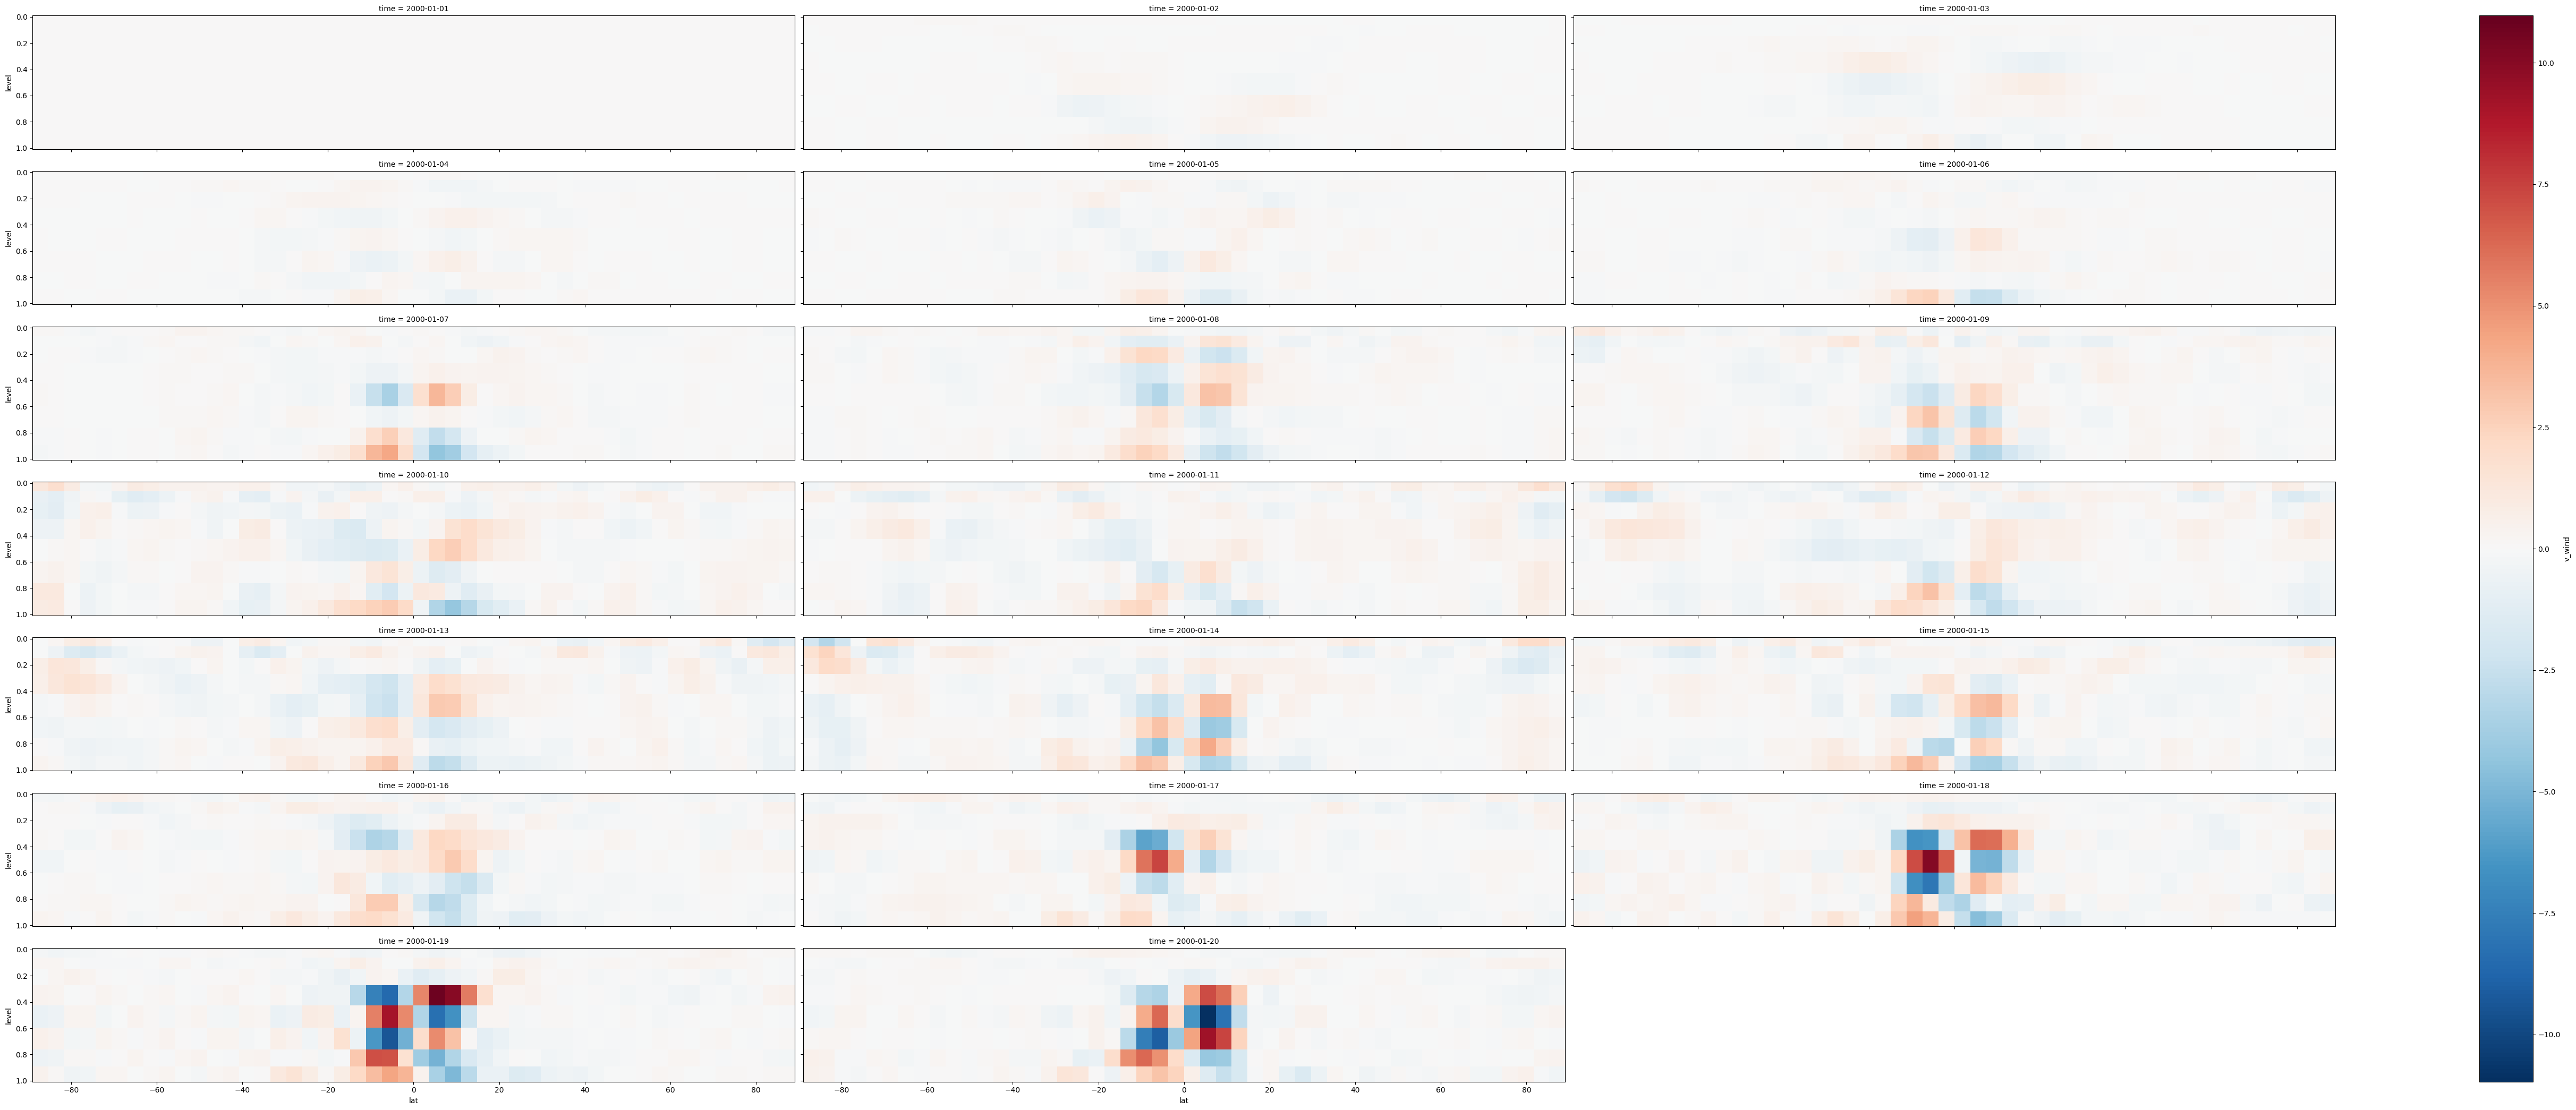

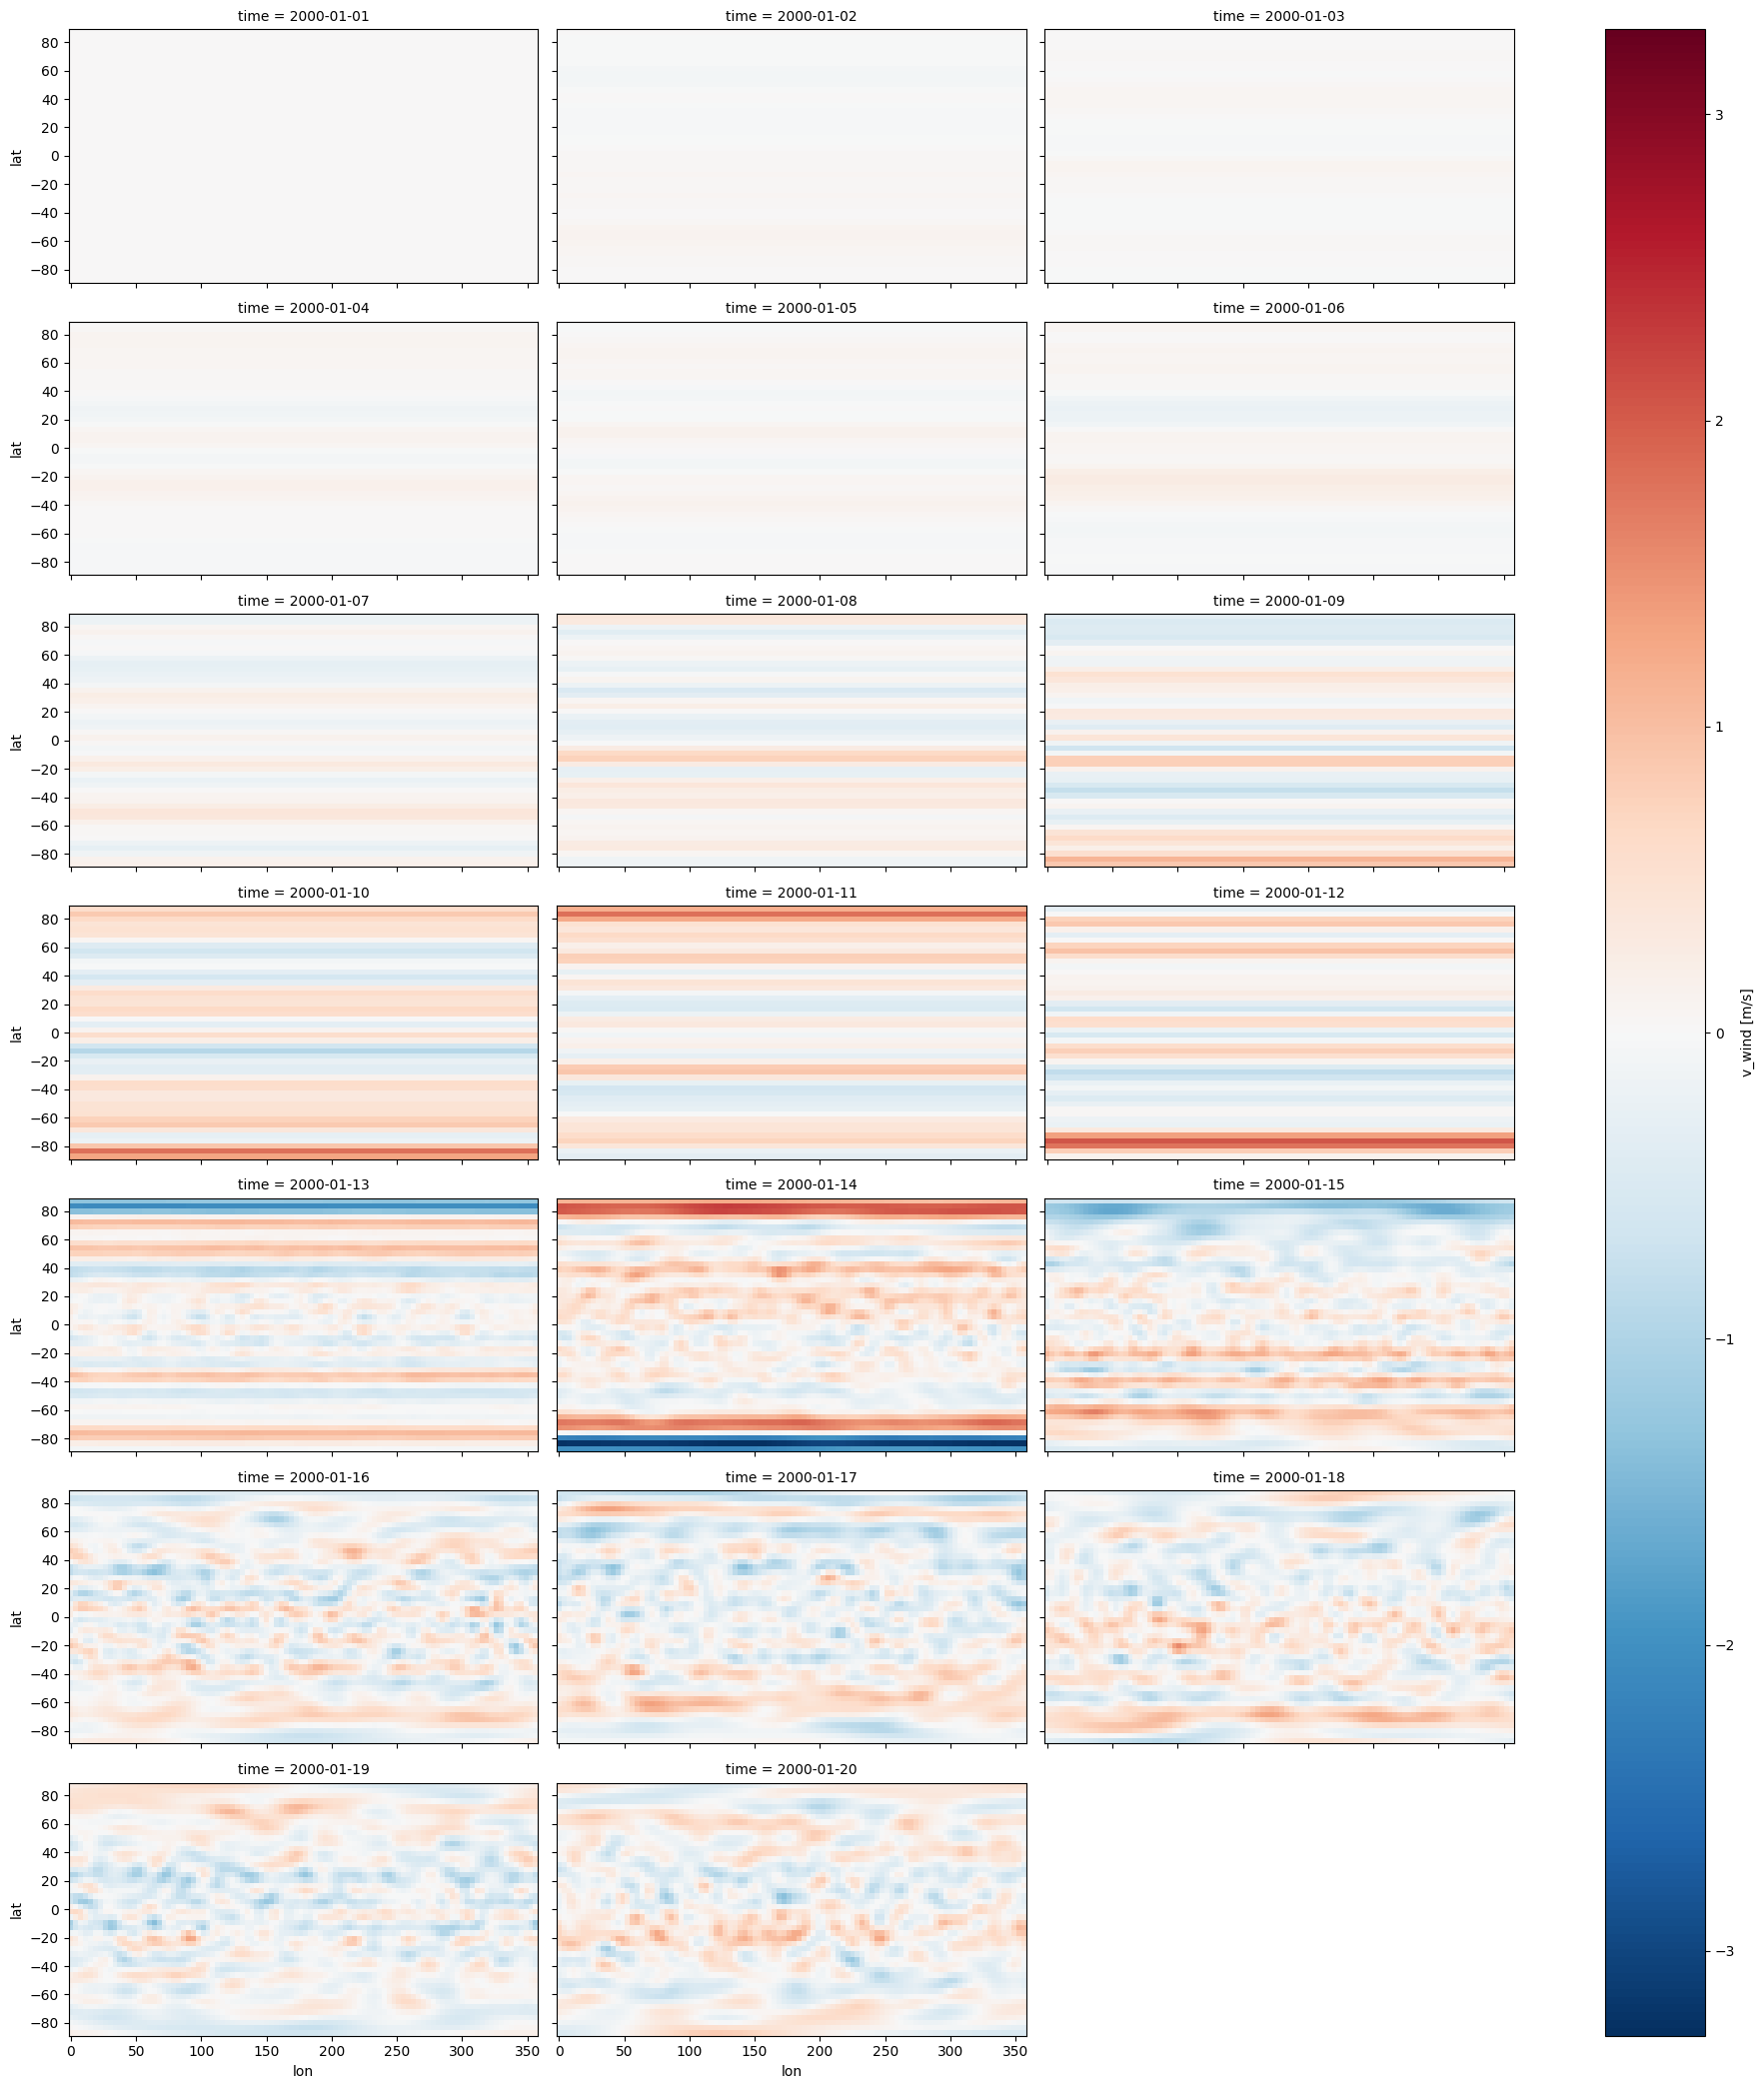

In [13]:
merged['v_wind'].mean('lon').plot(x='lat', y='level', col='time', col_wrap=3, aspect=6, yincrease=False)
merged['v_wind'].isel(level=-1).plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

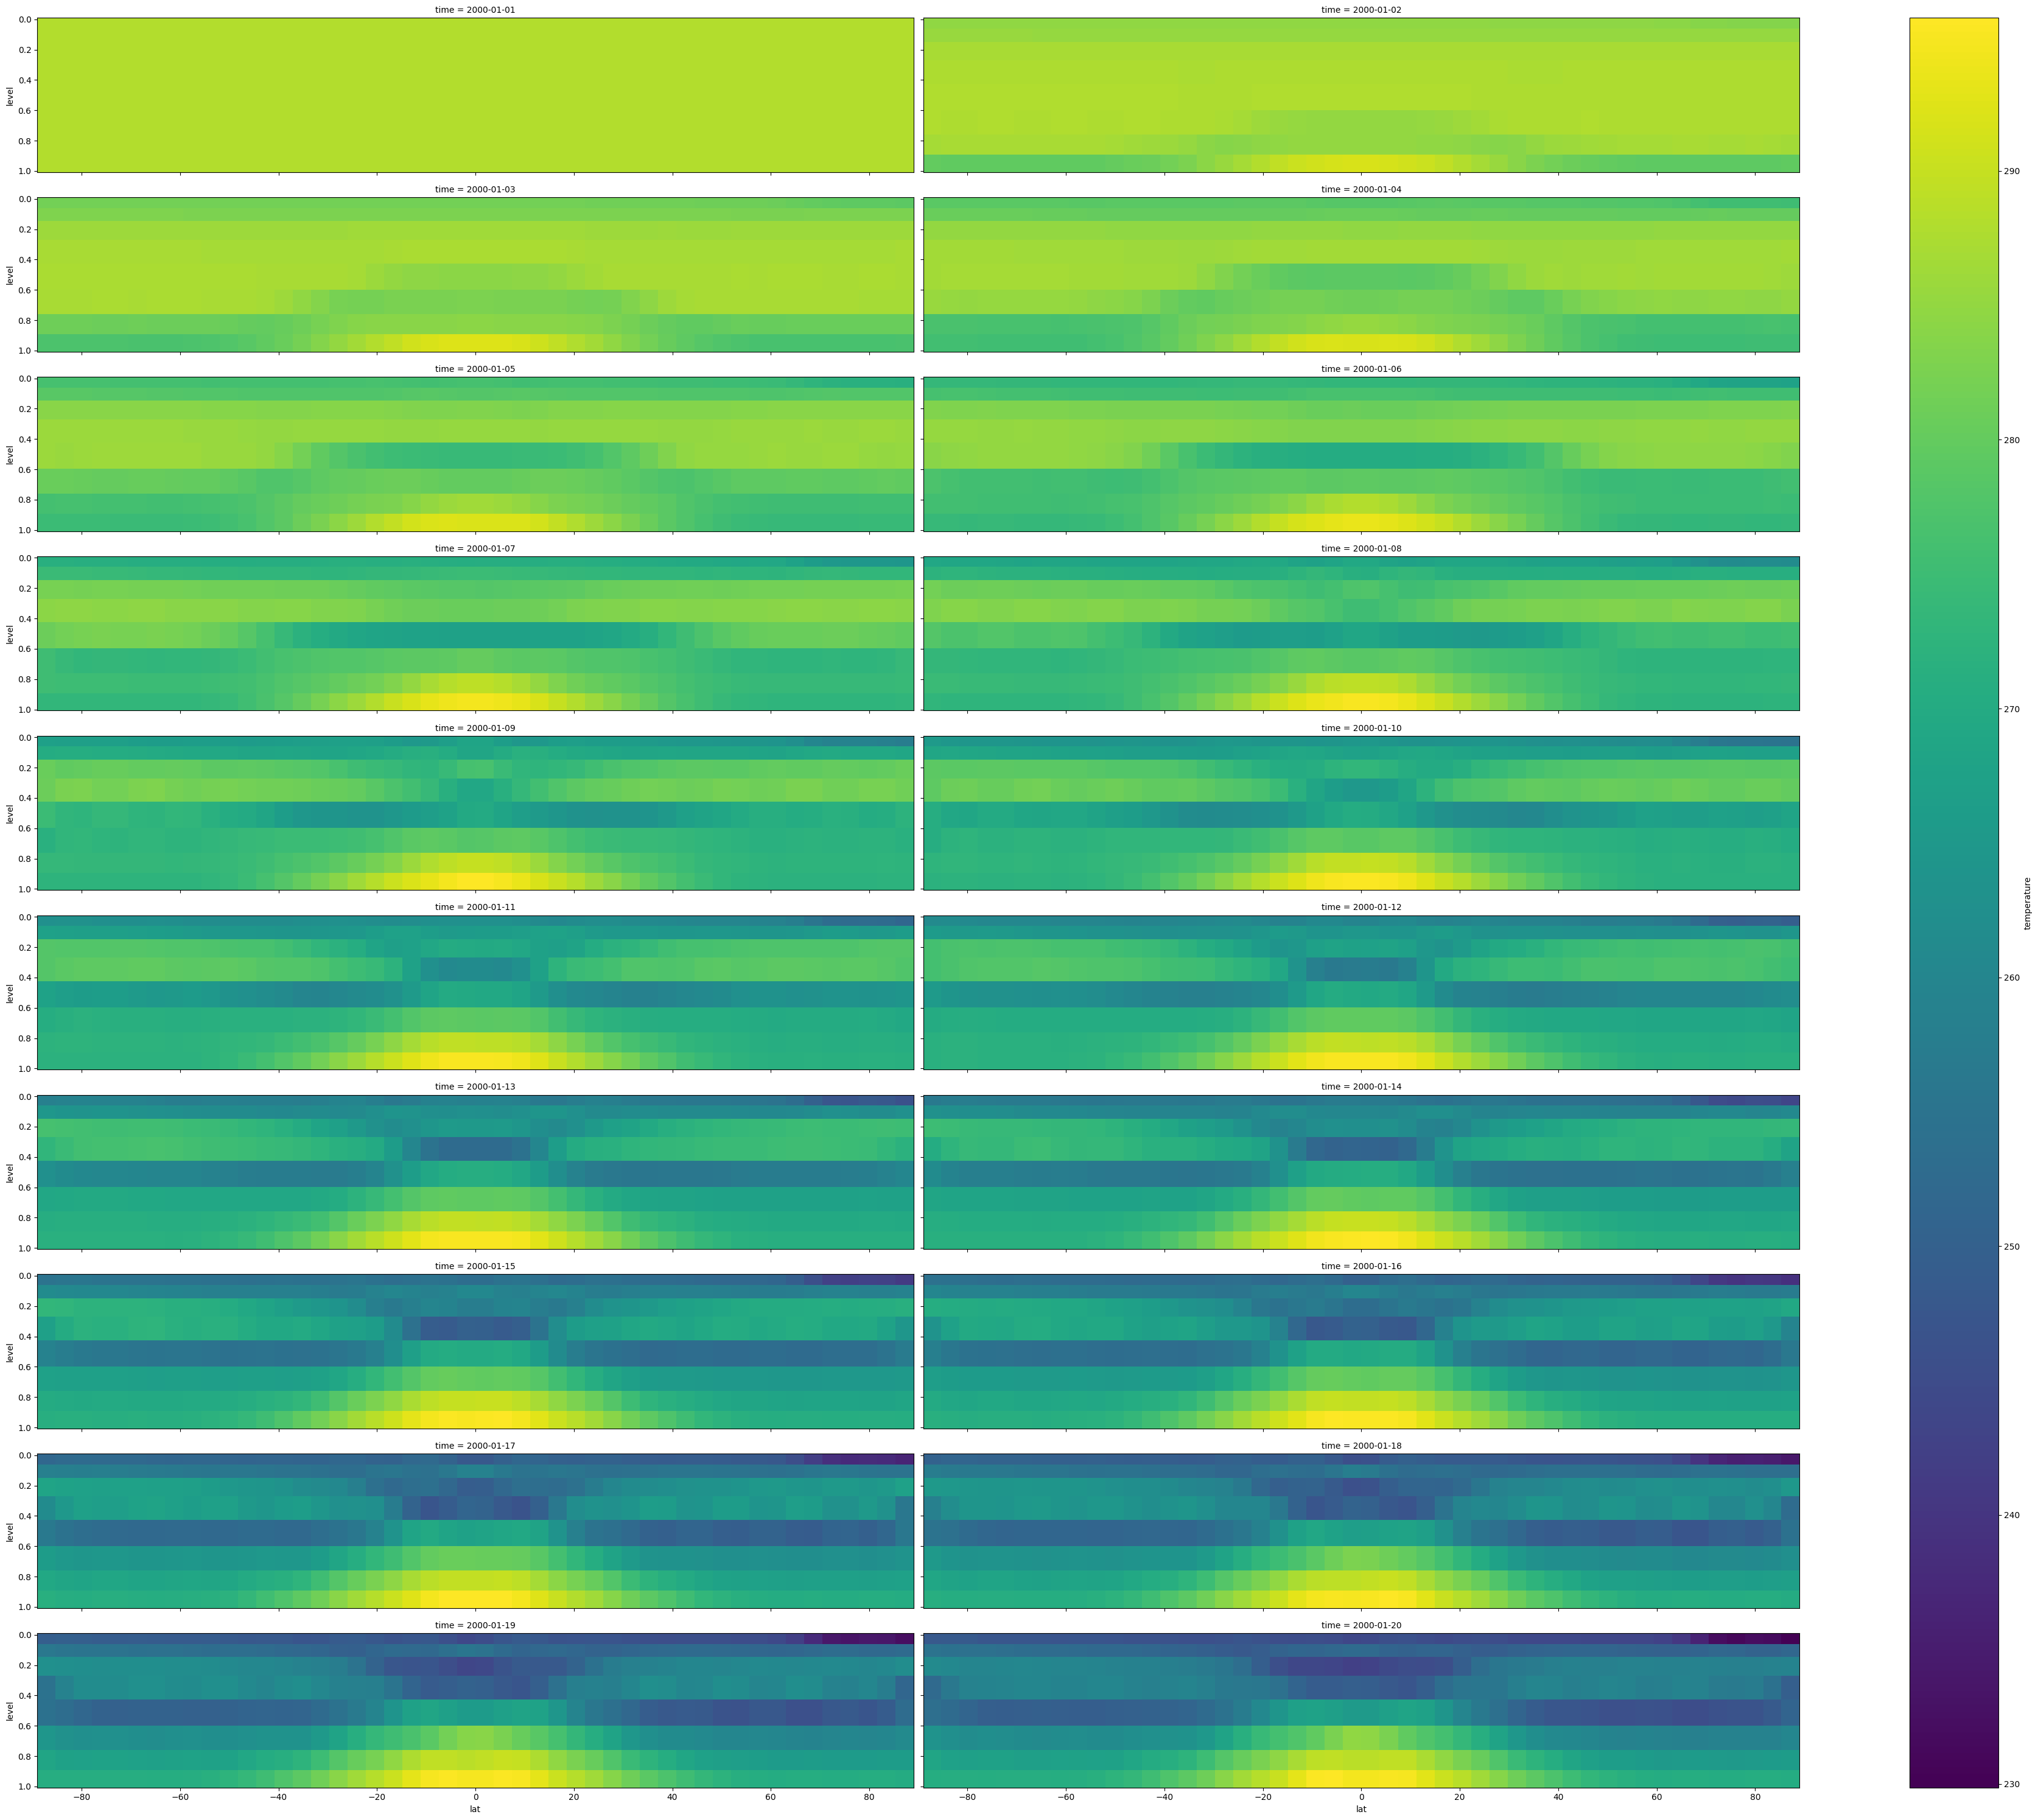

In [14]:
merged['temperature'].mean('lon').plot(x='lat', y='level', col='time', col_wrap=2, aspect=6, yincrease=False)

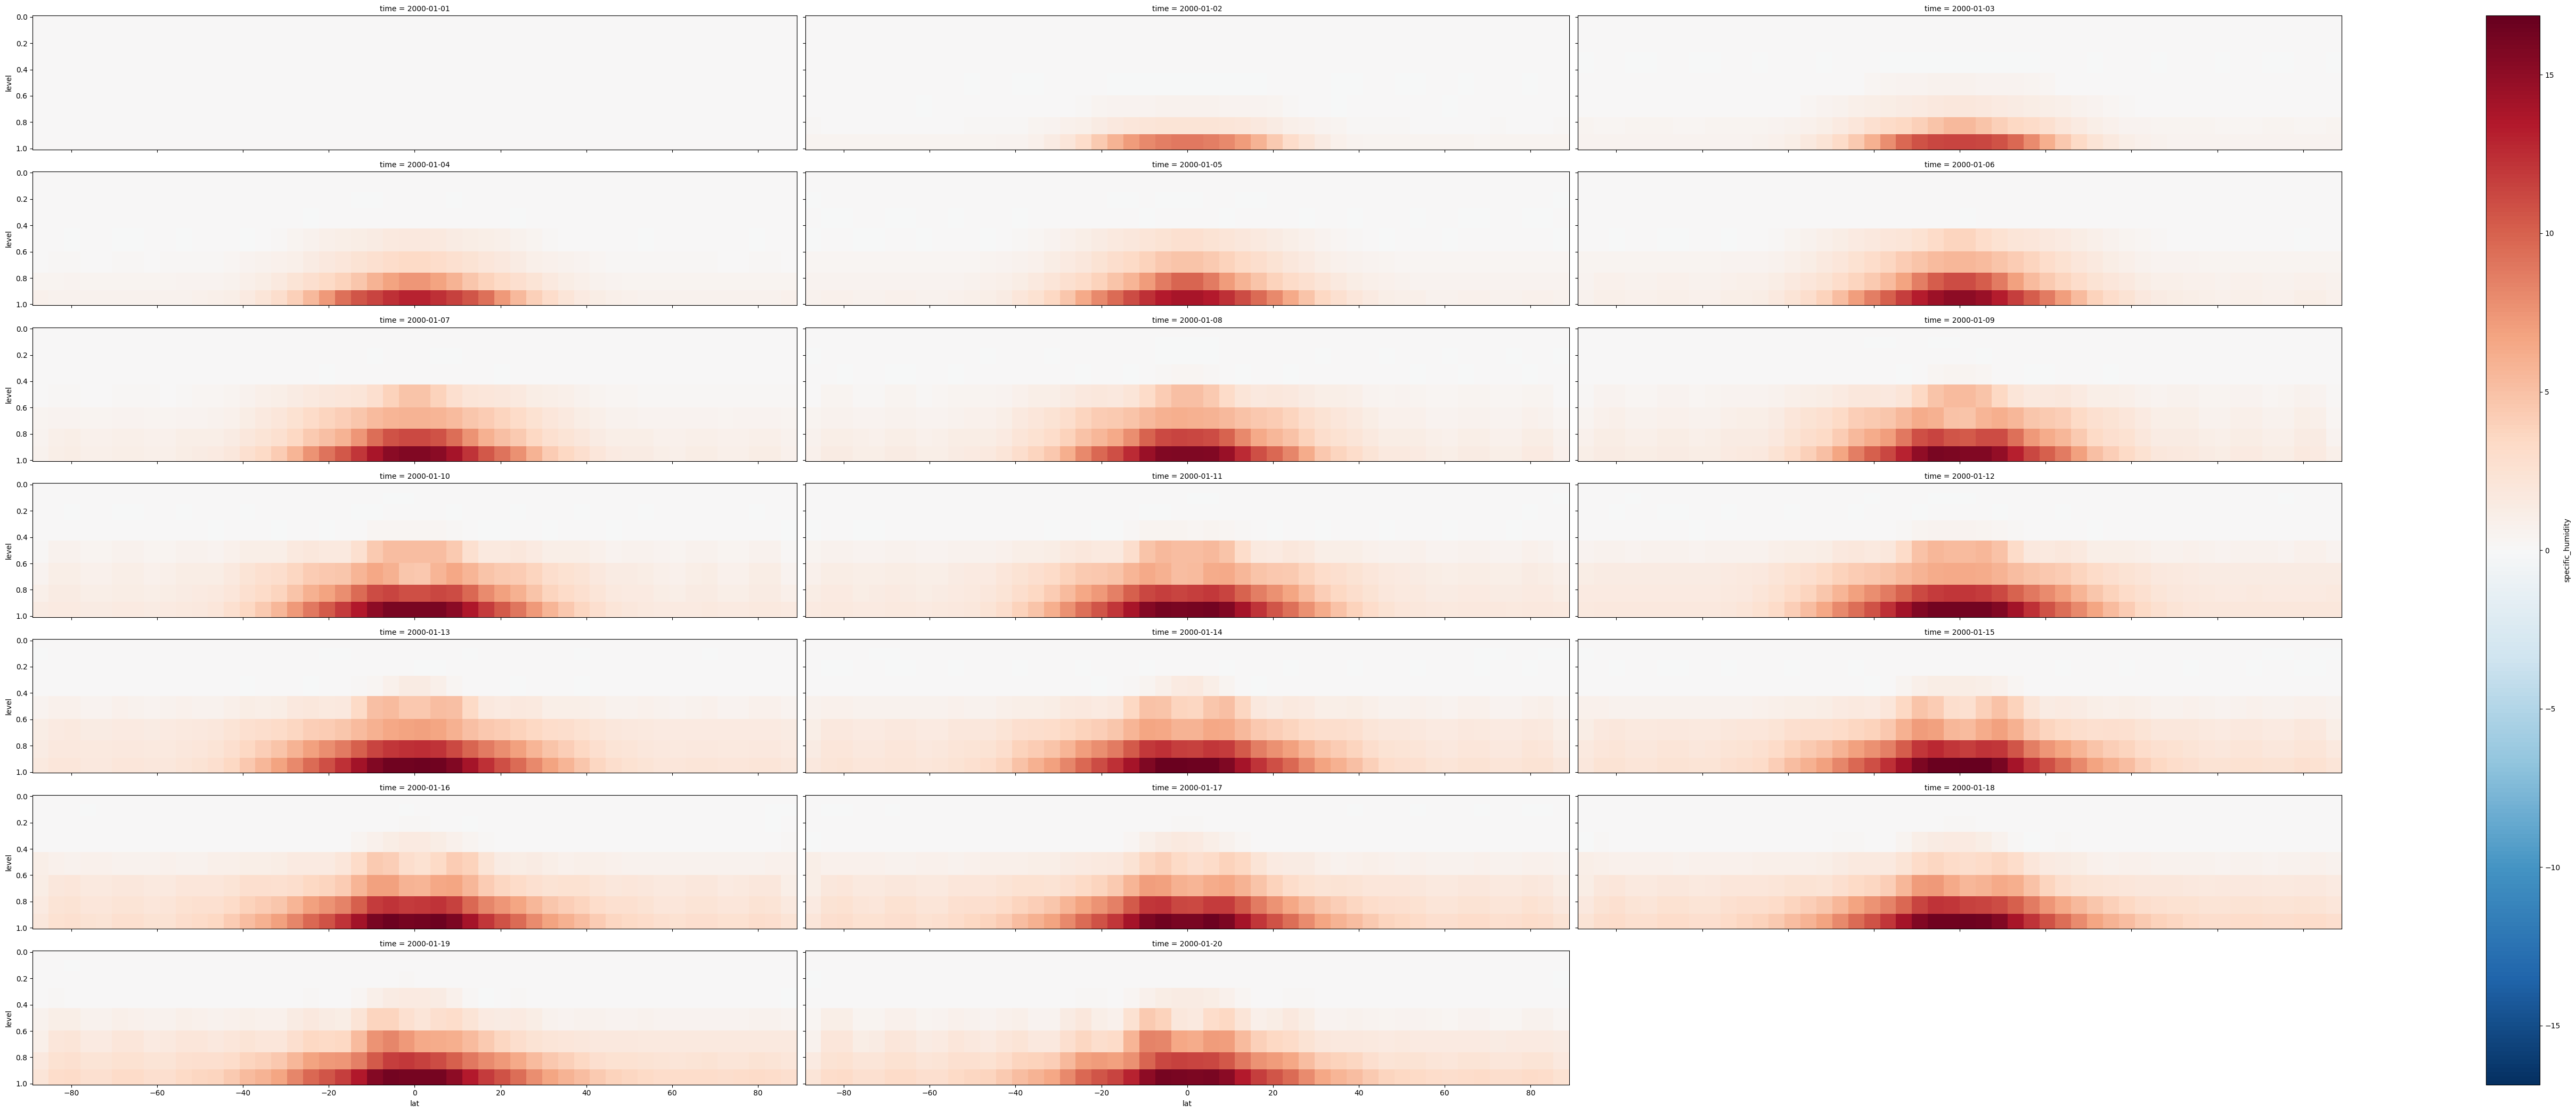

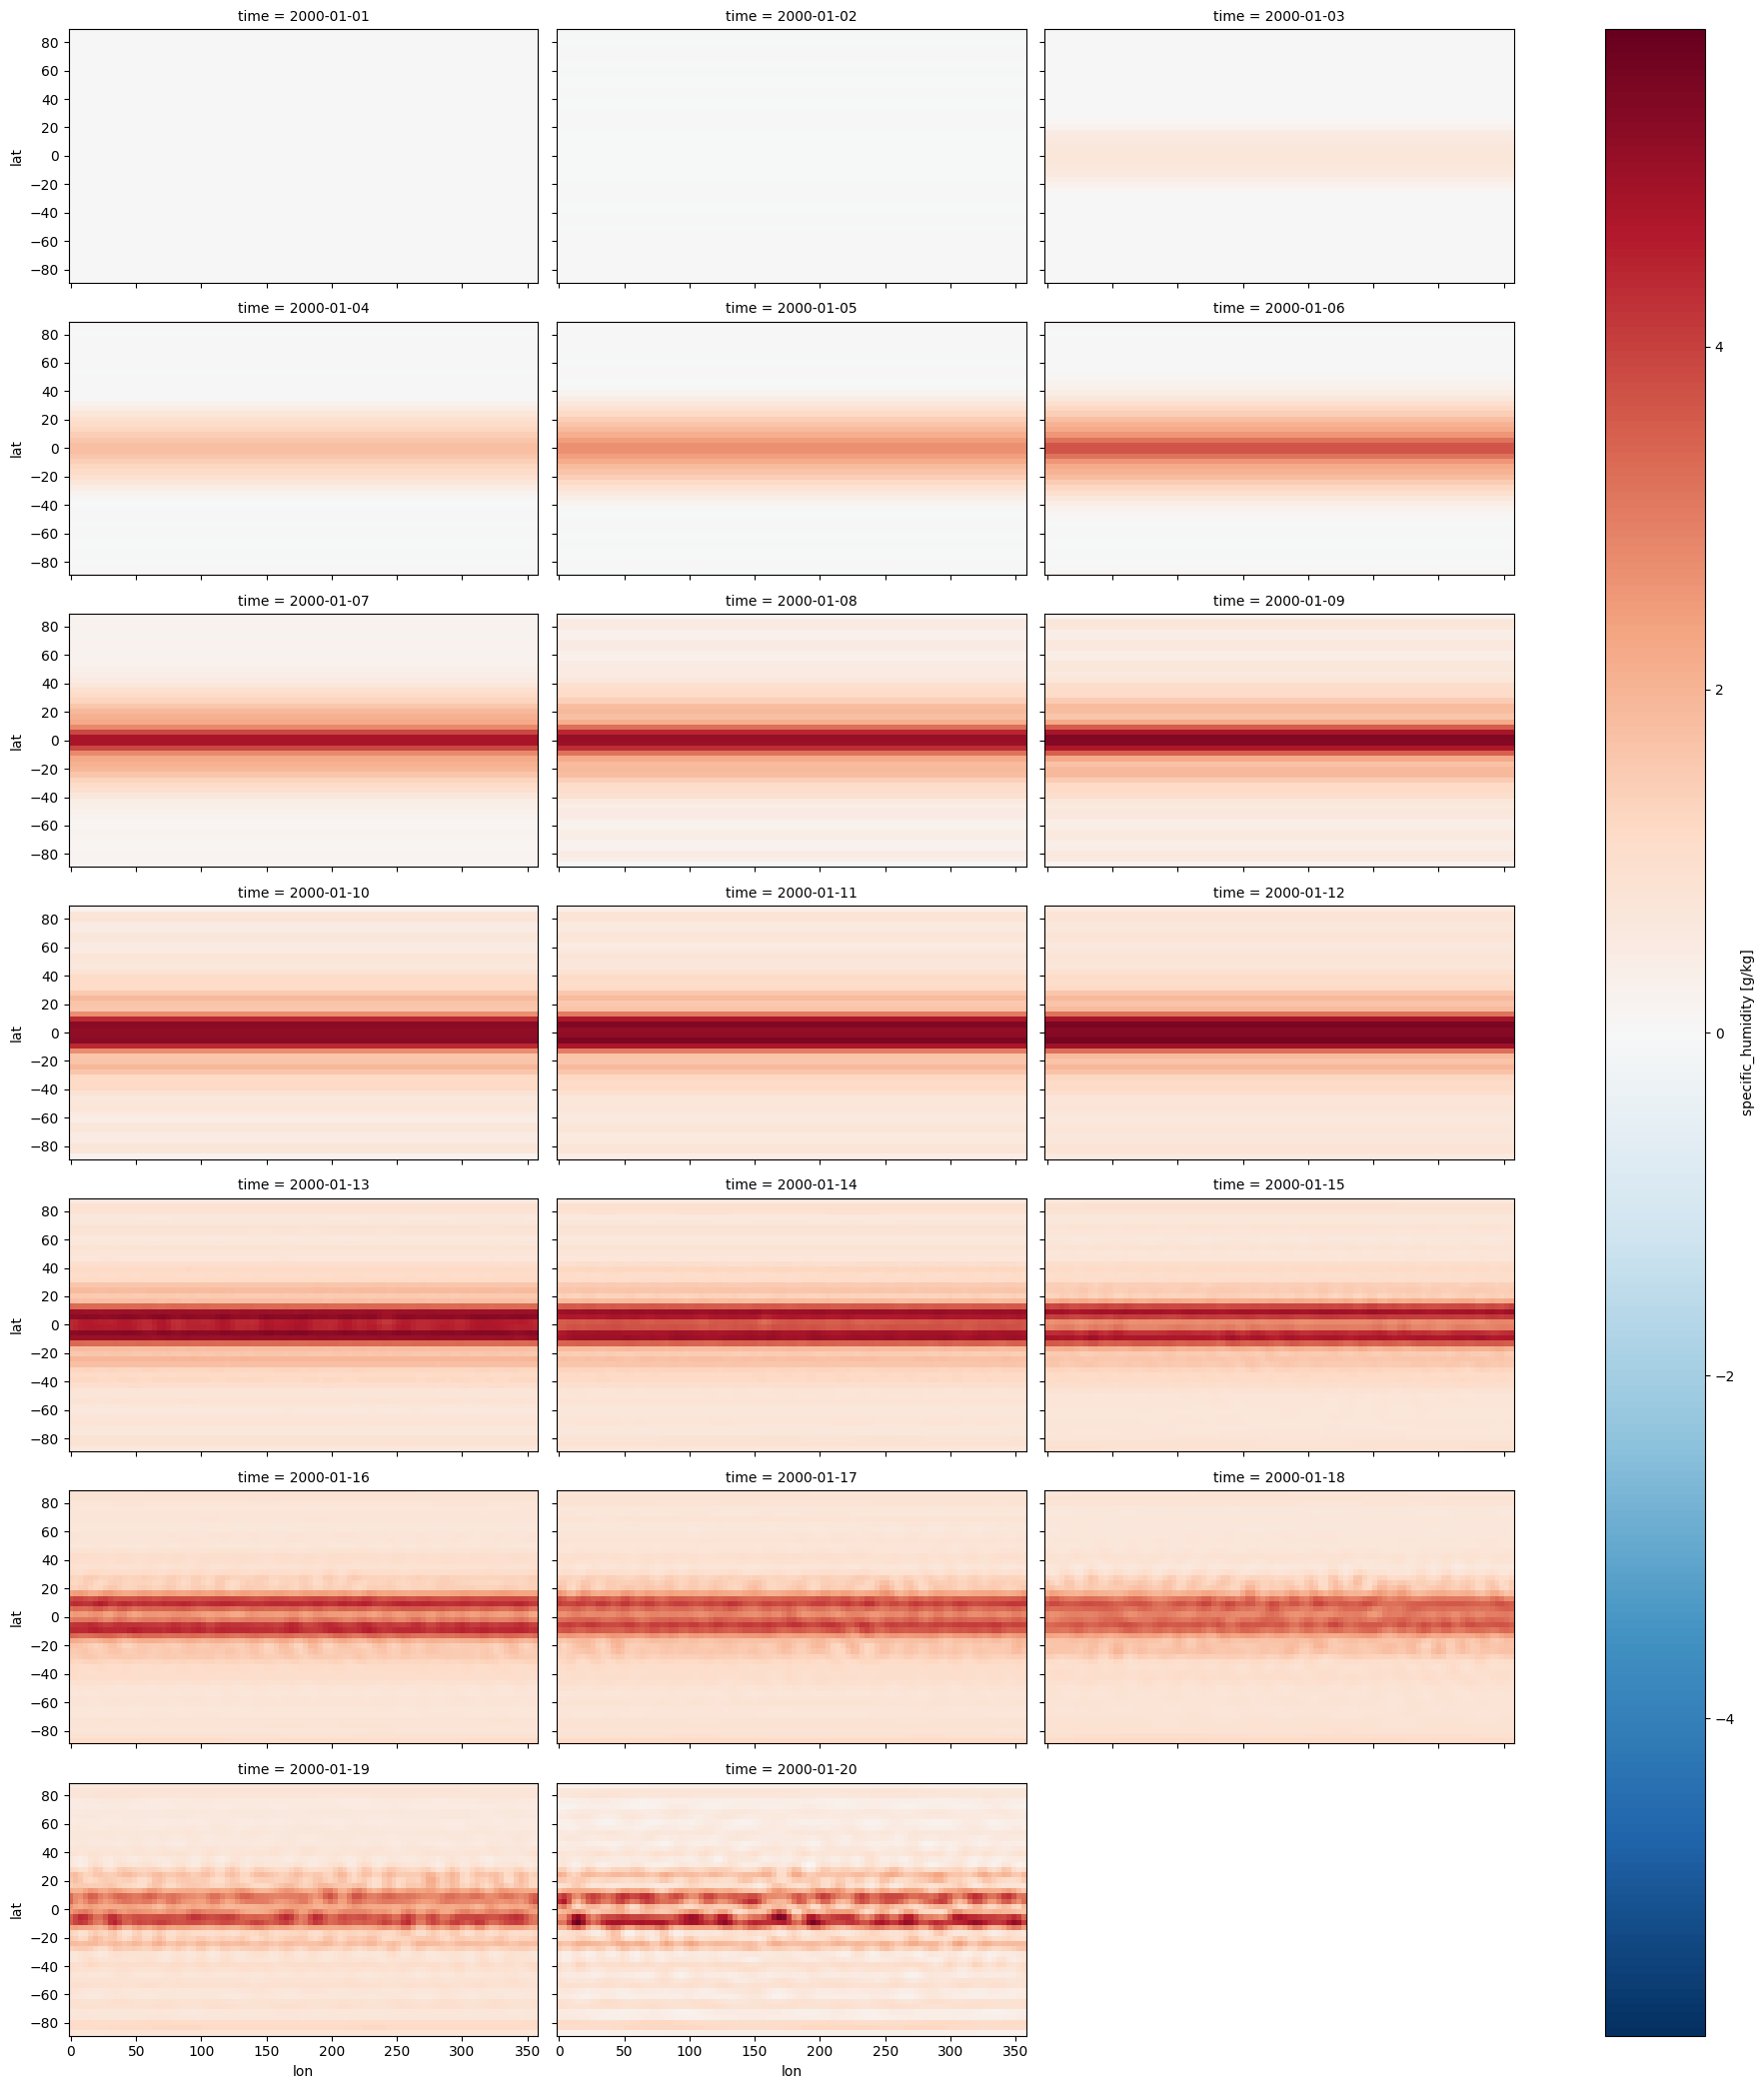

In [15]:
merged['specific_humidity'].mean('lon').plot(x='lat', y='level', col='time', col_wrap=3, aspect=6, yincrease=False)
merged['specific_humidity'].isel(level=3).plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

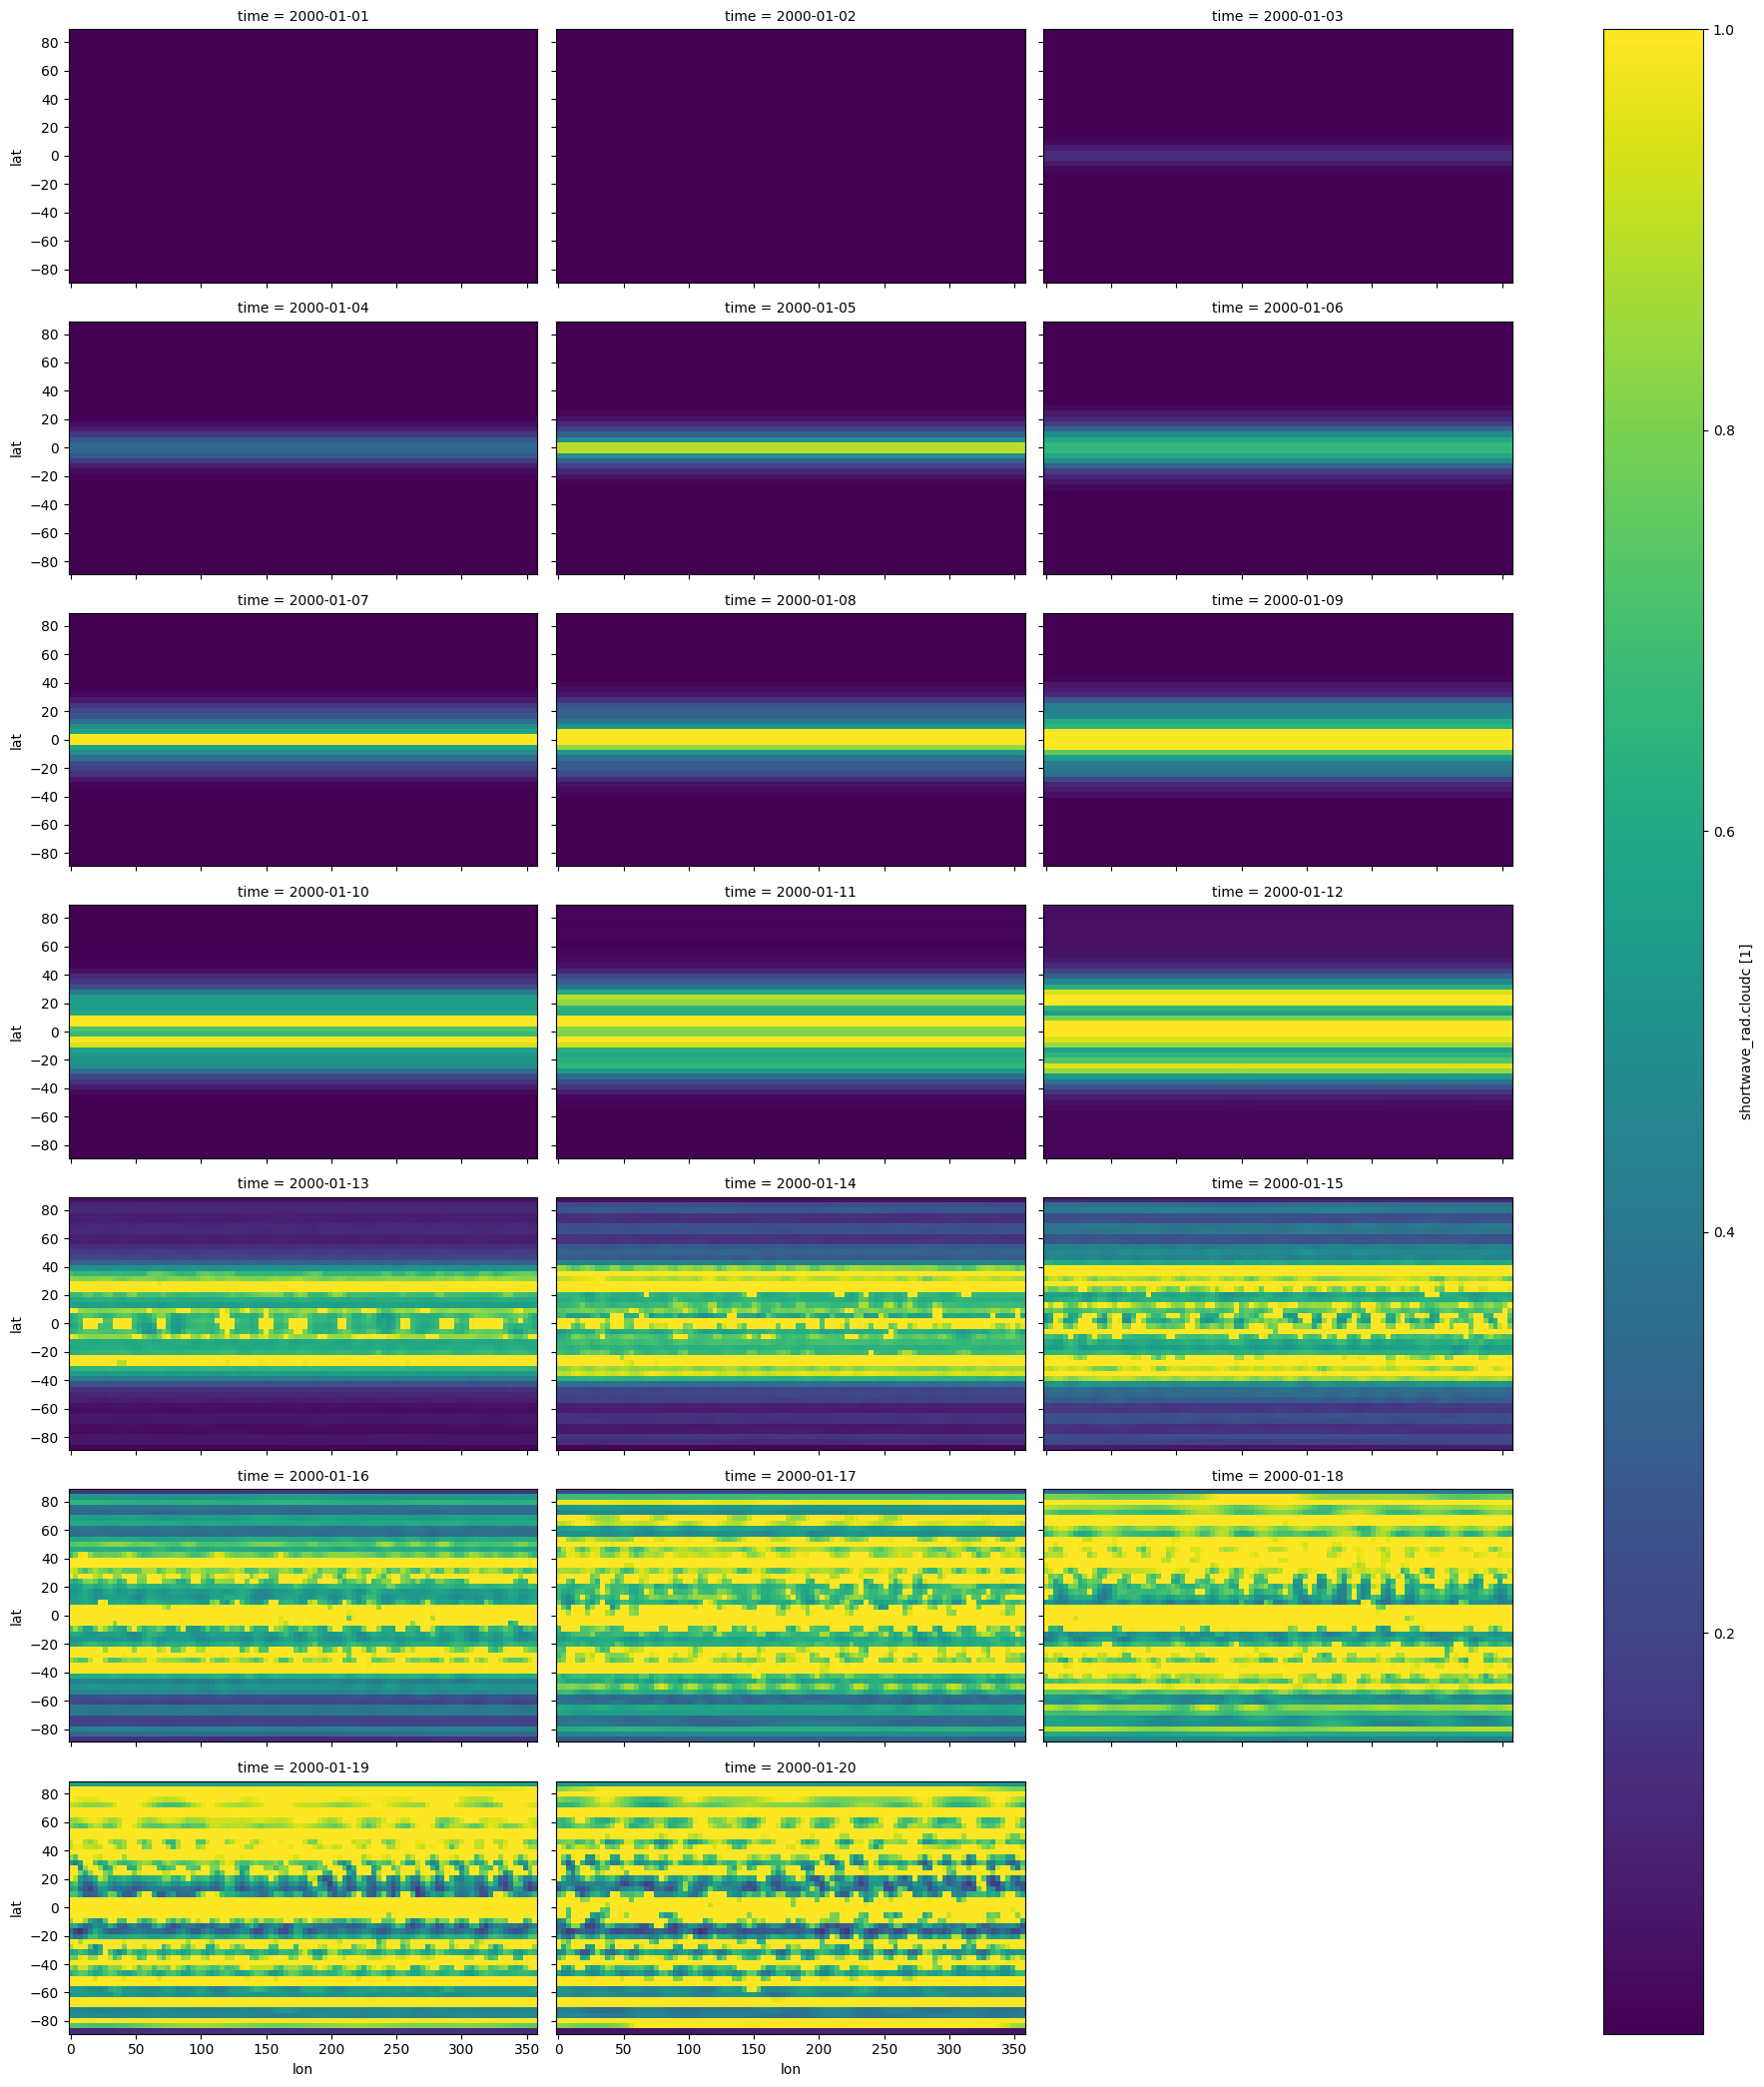

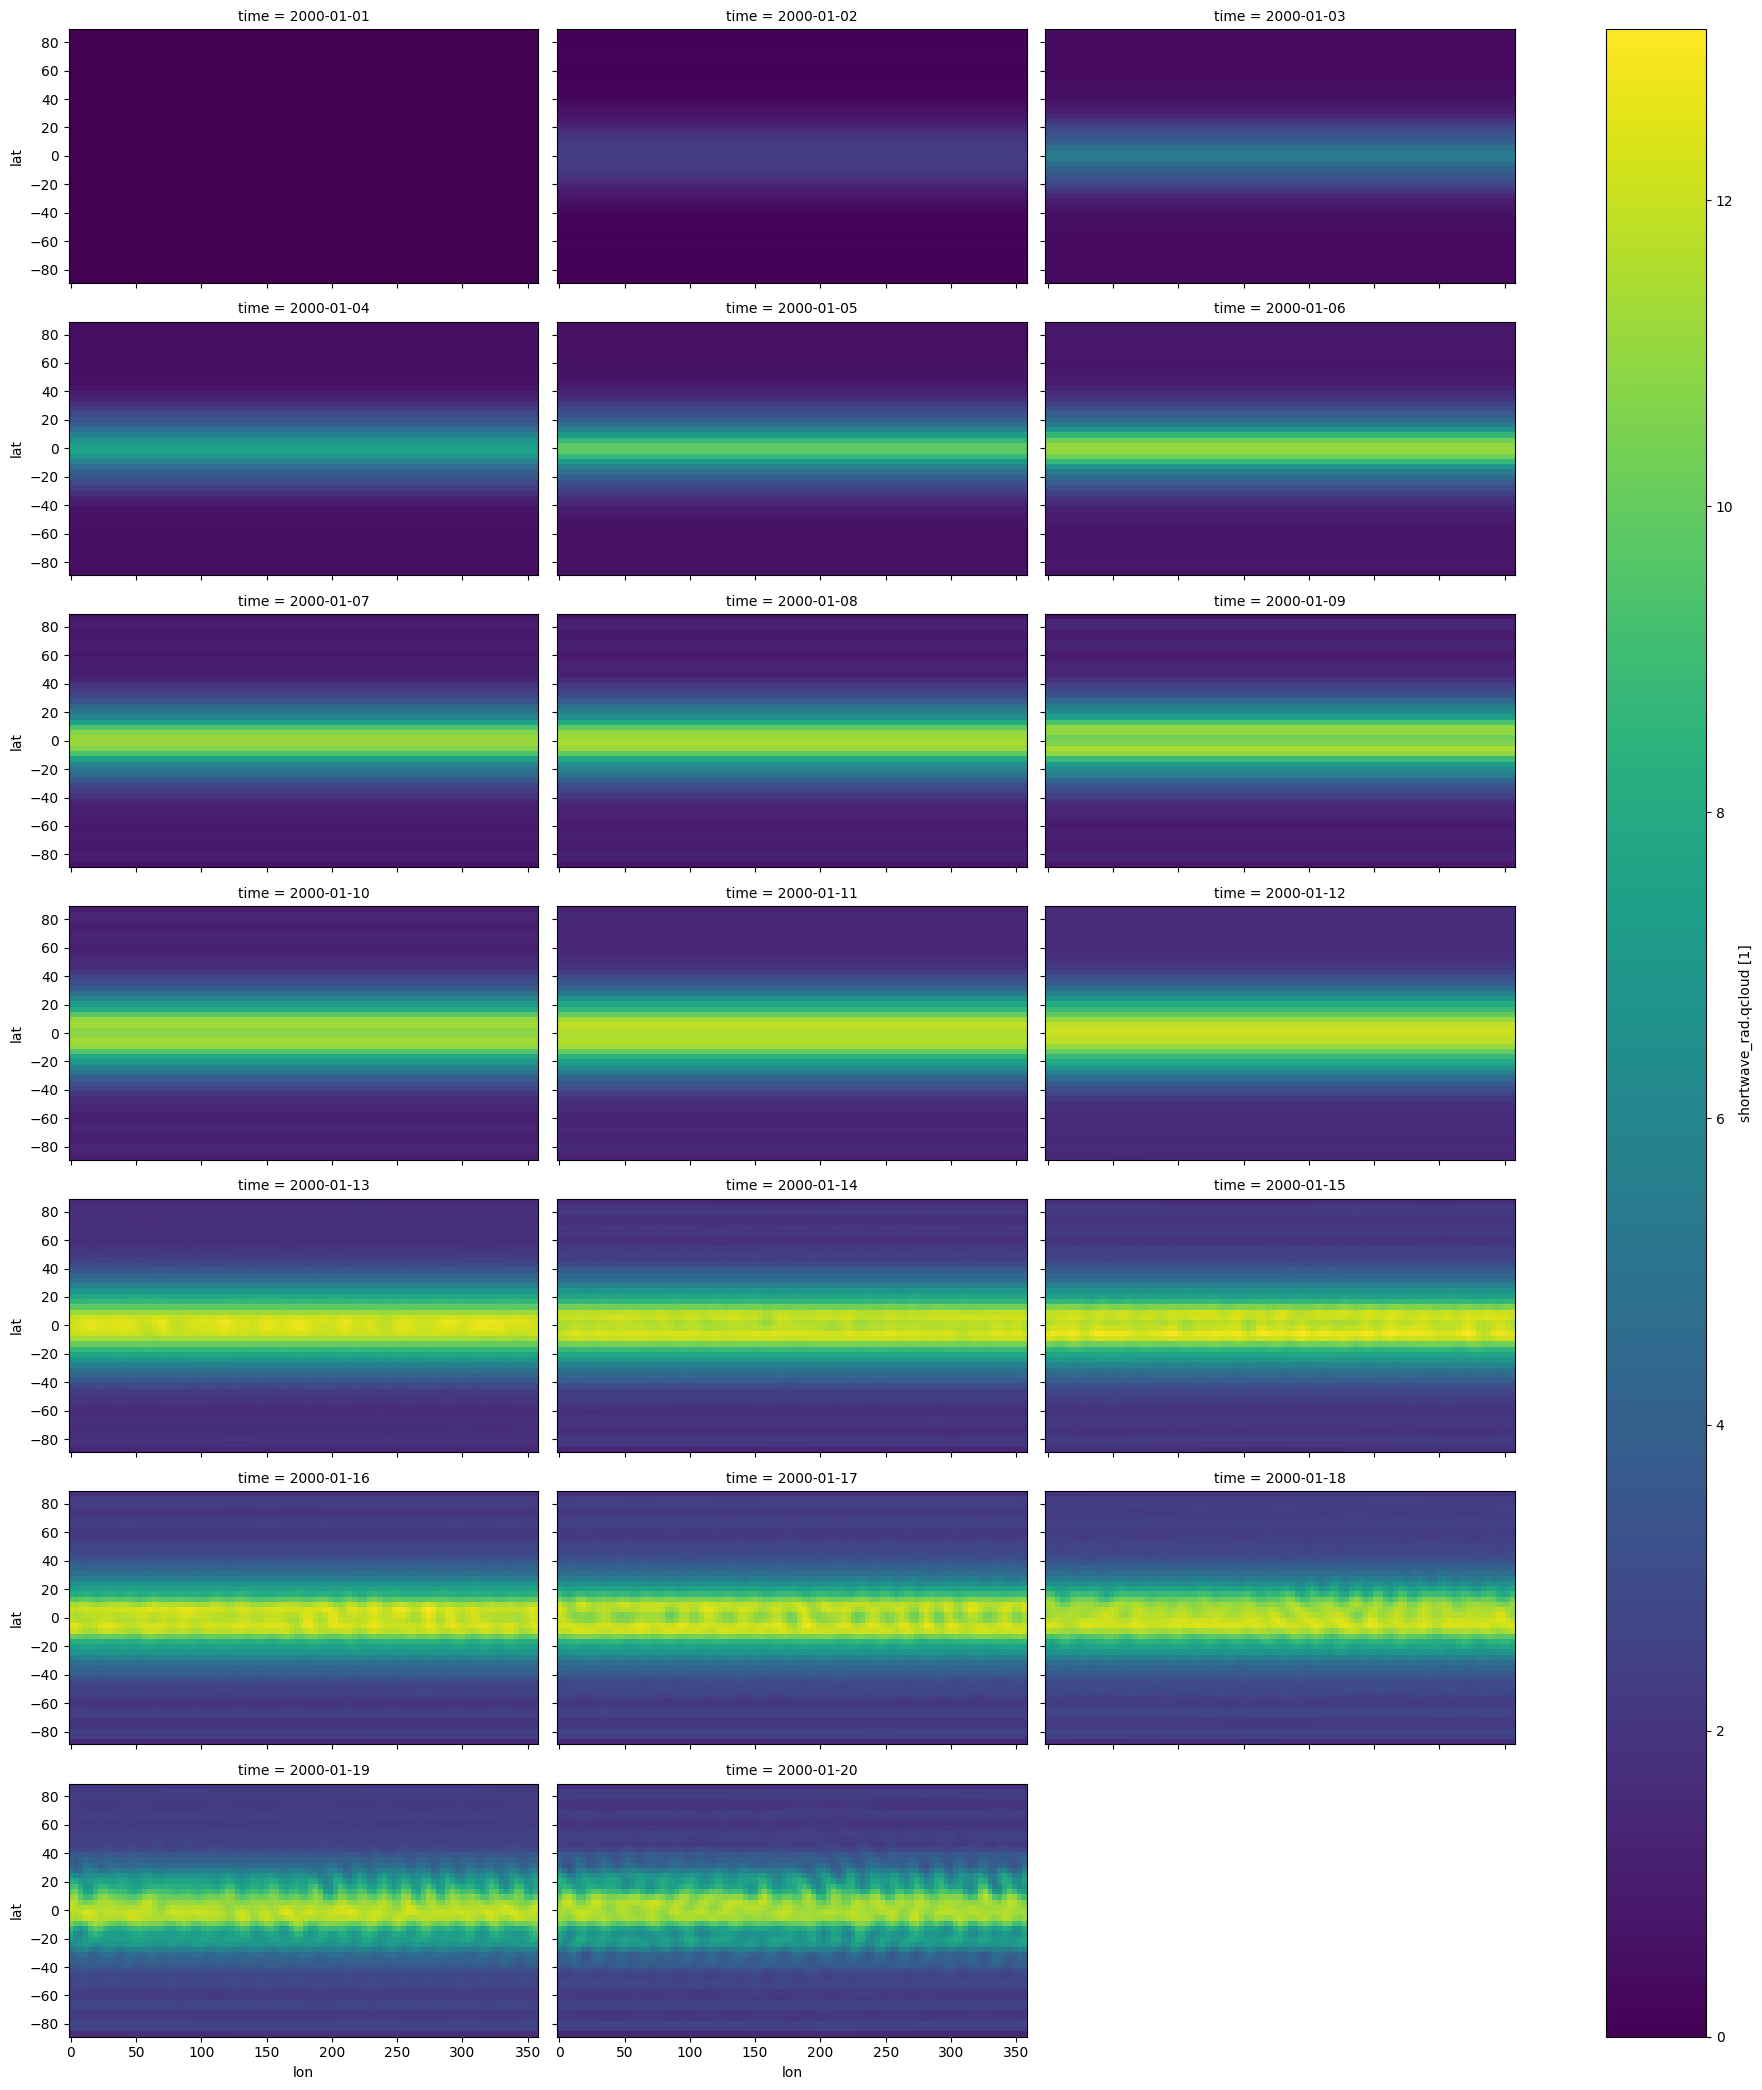

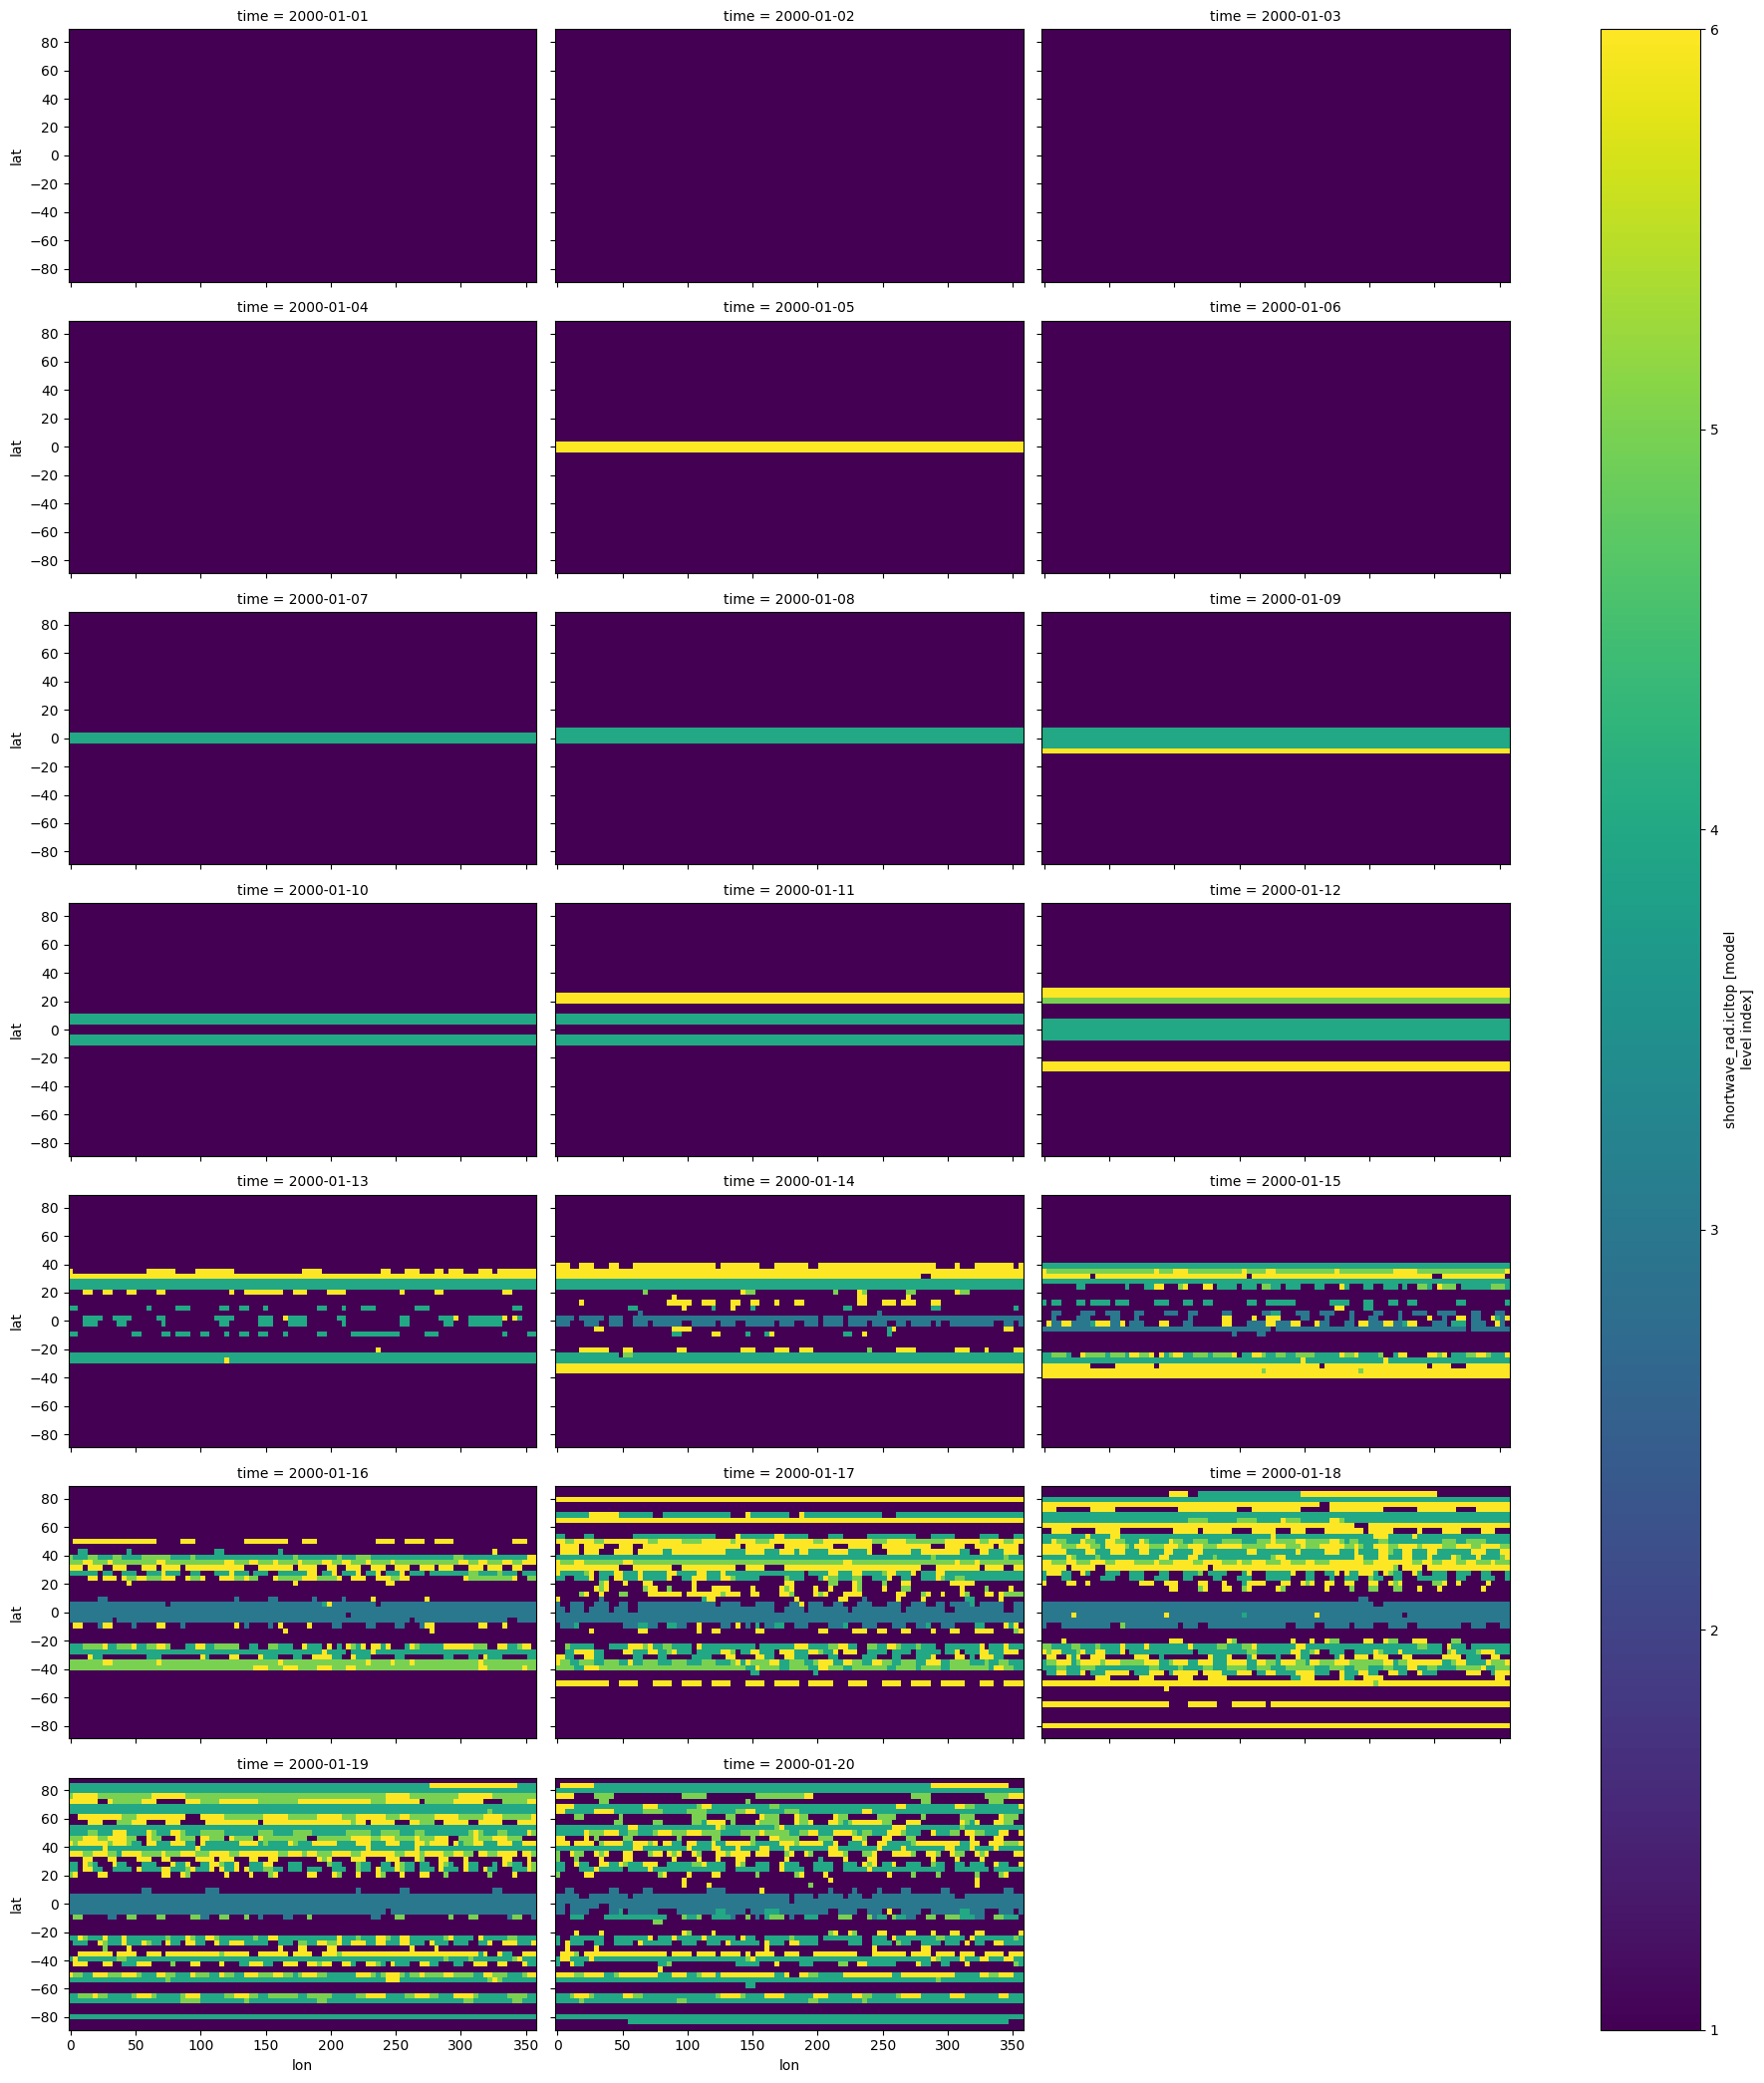

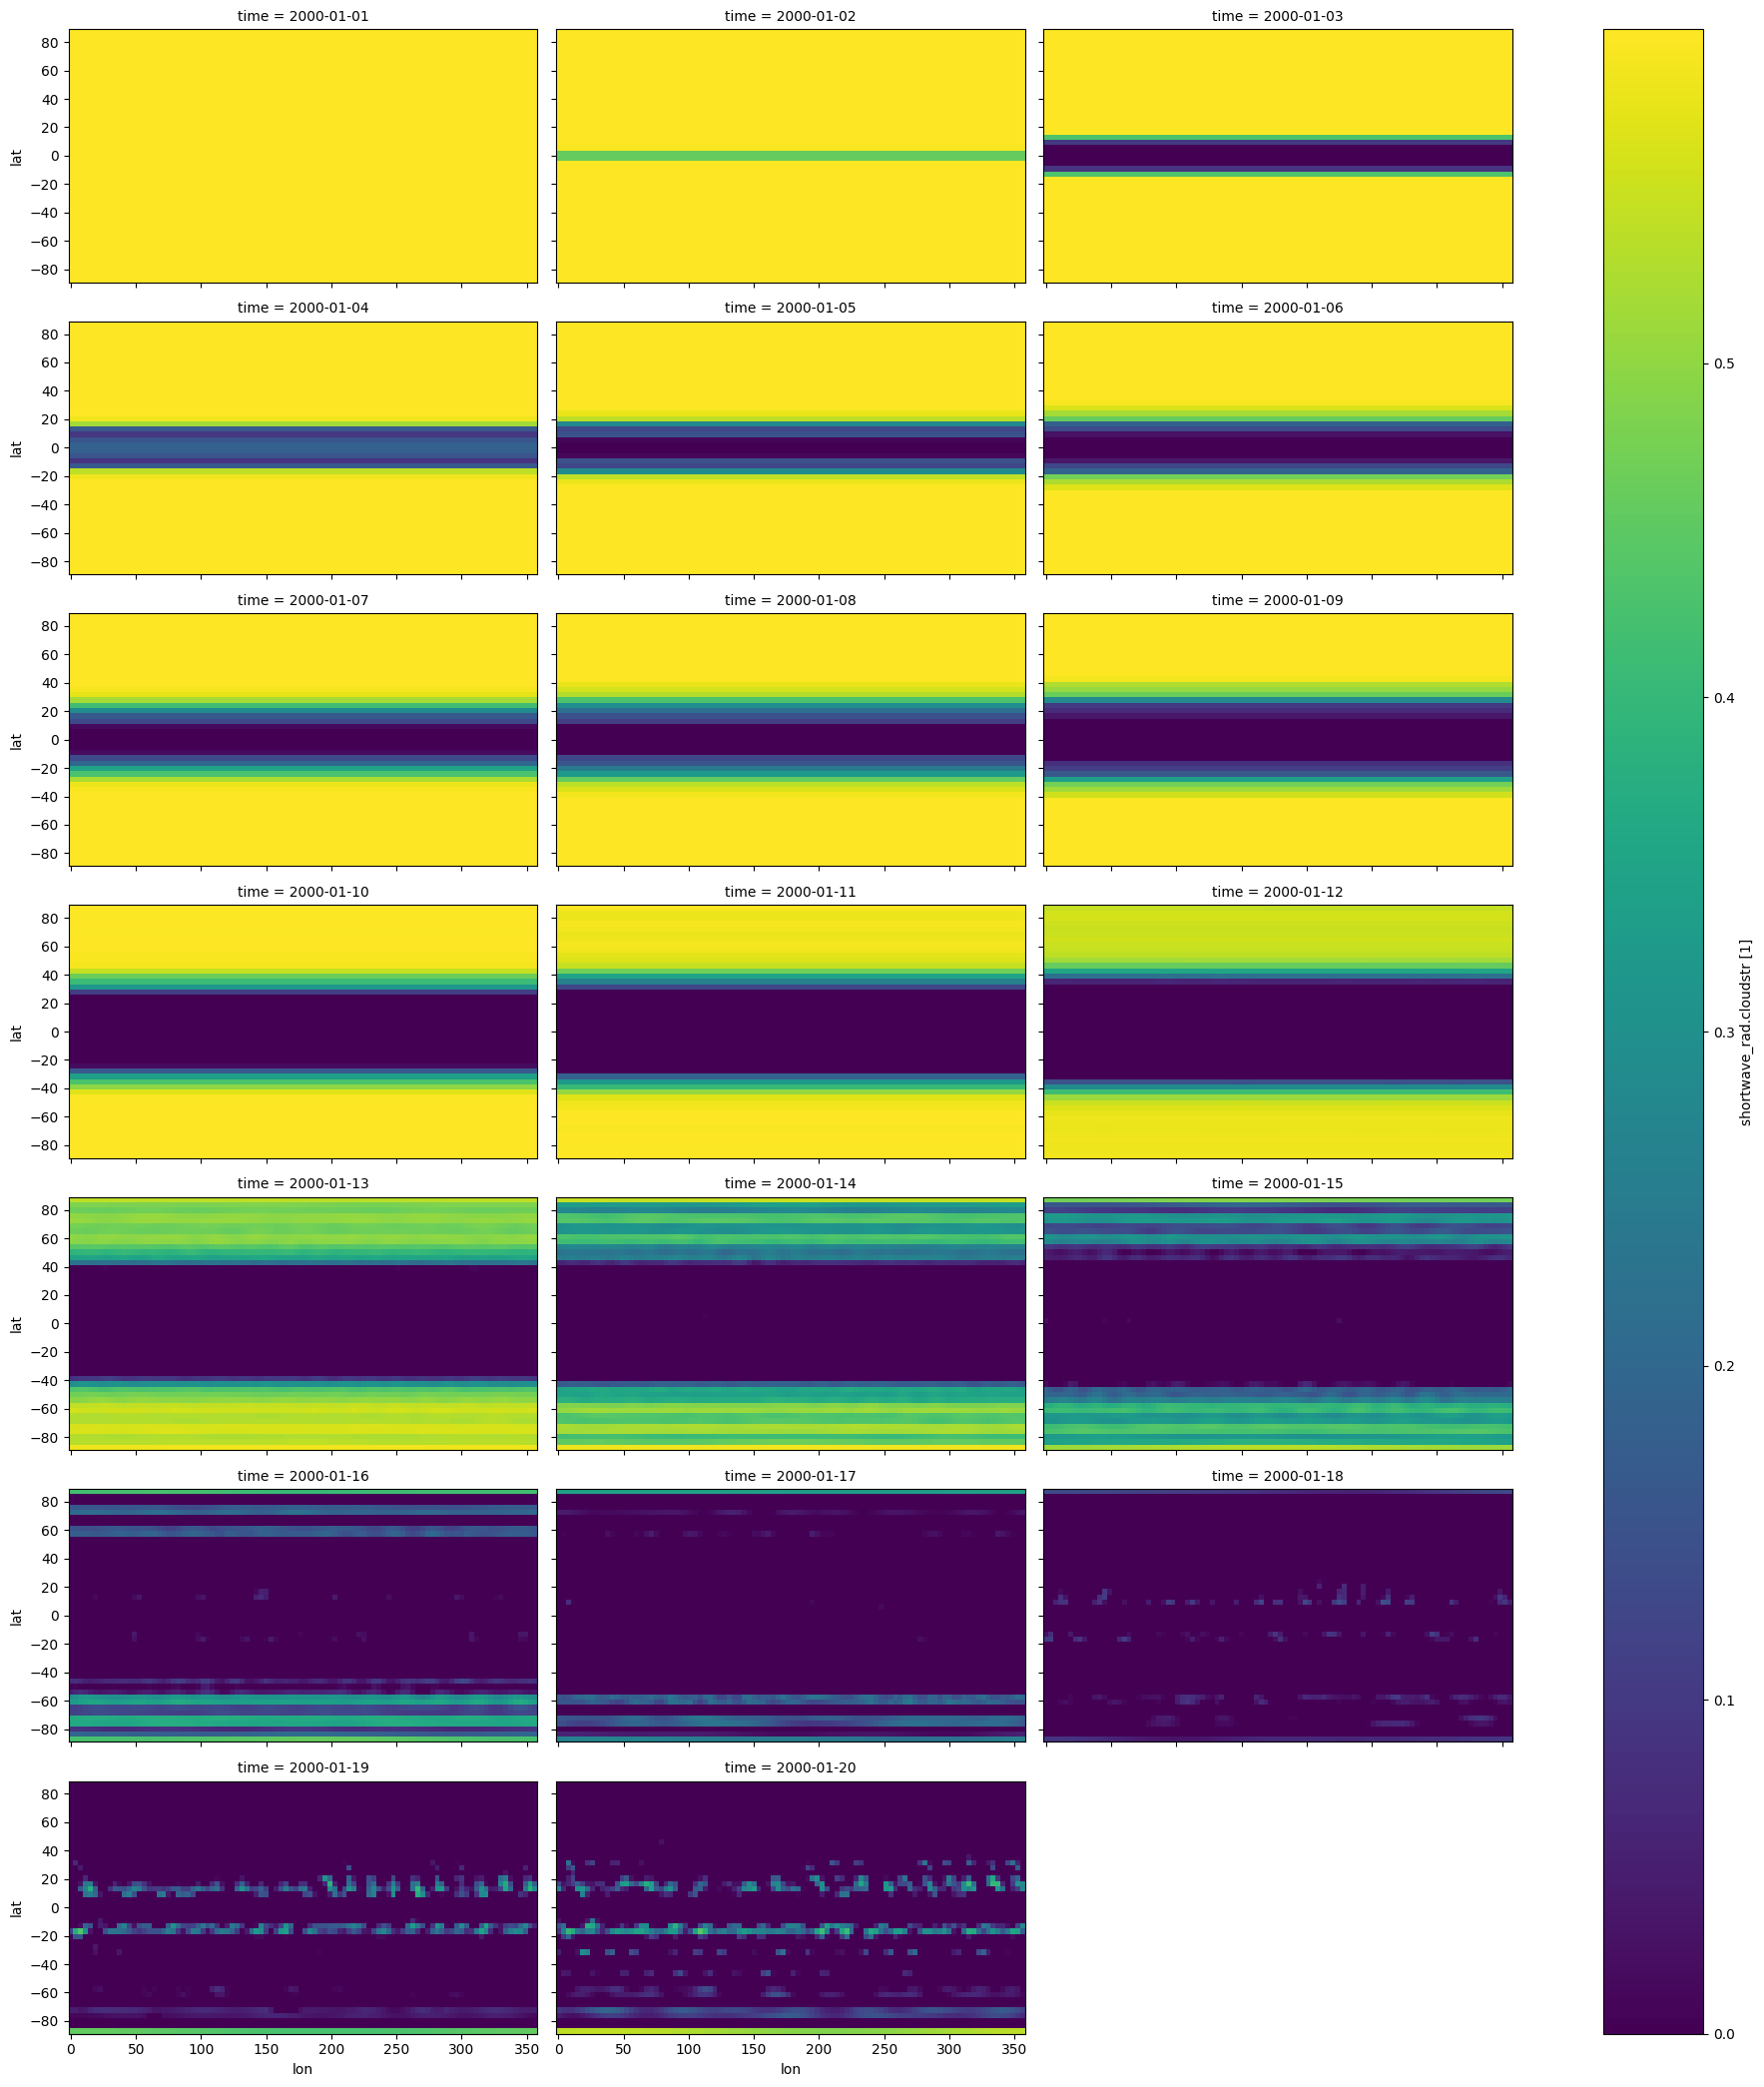

In [16]:
merged['shortwave_rad.cloudc'].plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)
merged['shortwave_rad.qcloud'].plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)
merged['shortwave_rad.icltop'].plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)
merged['shortwave_rad.cloudstr'].plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

###### 